In [2]:
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

# ── FUNCIONES DE PARSEO ──────────────────────────────────────────────────
def parse_eu_number(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().replace('%', '').replace(' ', '')
    s = s.replace('.', '').replace(',', '.')
    try:
        return float(s)
    except (ValueError, TypeError):
        return np.nan

def parse_us_number(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().replace('%', '').replace(' ', '').replace(',', '')
    try:
        return float(s)
    except (ValueError, TypeError):
        return np.nan

def parse_eu_date(s):
    return pd.to_datetime(s, format='%d.%m.%Y', errors='coerce')

def parse_us_date(s):
    return pd.to_datetime(s, format='%m/%d/%Y', errors='coerce')

# ── CARGA DE LOS 6 CSVs DIARIOS ──────────────────────────────────────────
# Nota: Se asume que los archivos están en la ruta /content/ (Google Colab)
try:
    ibex_raw  = pd.read_csv('/content/IBEX 35 Historical Data.csv')
    stoxx_raw = pd.read_csv('/content/Datos históricos del Euro Stoxx 50.csv')
    sp_raw    = pd.read_csv('/content/Datos históricos del S&P 500.csv')
    vix_raw   = pd.read_csv('/content/Datos históricos del S&P 500 VIX (2).csv')
    b10_raw   = pd.read_csv('/content/español a 10 años Datos Históricos Rendimiento de Bonos (1).csv')
    b1_raw    = pd.read_csv('/content/español a 1 año Datos Históricos Rendimiento de Bonos (1).csv')
except FileNotFoundError as e:
    print(f"Error al cargar archivos: {e}")

# Procesamiento de fechas y precios iniciales
ibex = pd.DataFrame({
    'date':       ibex_raw['Date'].apply(parse_us_date),
    'ibex_close': ibex_raw['Price'].apply(parse_us_number),
    'ibex_high':  ibex_raw['High'].apply(parse_us_number),
    'ibex_low':   ibex_raw['Low'].apply(parse_us_number),
}).dropna(subset=['date']).sort_values('date')

stoxx = pd.DataFrame({
    'date':        stoxx_raw['Fecha'].apply(parse_eu_date),
    'stoxx_close': stoxx_raw['Último'].apply(parse_eu_number),
    'stoxx_high':  stoxx_raw['Máximo'].apply(parse_eu_number),
    'stoxx_low':   stoxx_raw['Mínimo'].apply(parse_eu_number),
}).dropna(subset=['date']).sort_values('date')

sp = pd.DataFrame({
    'date':        sp_raw['Fecha'].apply(parse_eu_date),
    'sp_close':    sp_raw['Último'].apply(parse_eu_number),
    'sp_high':     sp_raw['Máximo'].apply(parse_eu_number),
    'sp_low':      sp_raw['Mínimo'].apply(parse_eu_number),
}).dropna(subset=['date']).sort_values('date')

vix = pd.DataFrame({
    'date':        vix_raw['Fecha'].apply(parse_eu_date),
    'vix_close':   vix_raw['Último'].apply(parse_eu_number),
    'vix_high':    vix_raw['Máximo'].apply(parse_eu_number),
    'vix_low':     vix_raw['Mínimo'].apply(parse_eu_number),
}).dropna(subset=['date']).sort_values('date')

b10 = pd.DataFrame({
    'date':         b10_raw['Fecha'].apply(parse_eu_date),
    'bond10_close': b10_raw['Último'].apply(parse_eu_number),
}).dropna(subset=['date']).sort_values('date')

b1 = pd.DataFrame({
    'date':        b1_raw['Fecha'].apply(parse_eu_date),
    'bond1_close': b1_raw['Último'].apply(parse_eu_number),
}).dropna(subset=['date']).sort_values('date')

# ── MERGE DIARIO ─────────────────────────────────────────────────────────
df_daily = ibex.copy()
for other in [stoxx, sp, vix, b10, b1]:
    df_daily = df_daily.merge(other, on='date', how='left')
df_daily = df_daily.sort_values('date').set_index('date')

# ── RESAMPLE A SEMANAL (cierre = viernes) ────────────────────────────────
OHLC_MAP = {
    'ibex_close': 'last',  'ibex_high': 'max',  'ibex_low': 'min',
    'stoxx_close': 'last', 'stoxx_high': 'max', 'stoxx_low': 'min',
    'sp_close': 'last',    'sp_high': 'max',    'sp_low': 'min',
    'vix_close': 'last',   'vix_high': 'max',   'vix_low': 'min',
    'bond10_close': 'last', 'bond1_close': 'last',
}
d = df_daily.resample('W-FRI').agg(OHLC_MAP).dropna(subset=['ibex_close', 'sp_close'])

ALL_LAGS = [1, 2, 3, 4, 5, 10, 20, 50]
ALL_EMA  = [2, 3, 4, 5, 10, 20, 50]
RET_COLS = ['ibex_ret', 'stoxx_ret', 'sp_ret', 'vix_ret', 'bond10_ret', 'bond1_ret']
HL_ASSETS = [('ibex', 'ibex_high', 'ibex_low'), ('stoxx', 'stoxx_high', 'stoxx_low'),
             ('sp', 'sp_high', 'sp_low'),       ('vix', 'vix_high', 'vix_low')]

# ── RETORNOS SEMANALES ───────────────────────────────────────────────────
for col in ['ibex', 'stoxx', 'sp', 'vix', 'bond10', 'bond1']:
    d[f'{col}_ret'] = d[f'{col}_close'].pct_change().clip(-0.3, 0.3)

# ── TARGET SIN DATA LEAKAGE ──────────────────────────────────────────────
d['TARGET_ibex_ret_fwd1'] = d['ibex_ret'].shift(-1)

# ── FEATURES POR ACTIVO ──────────────────────────────────────────────────
for col in RET_COLS:
    px = col.replace('_ret', '')
    # Lags y EMAs
    for l in ALL_LAGS:
        d[f'{col}_lag{l}'] = d[col].shift(l)
    for w in ALL_EMA:
        d[f'{col}_ema{w}'] = d[col].ewm(span=w, adjust=False).mean()

    # MACD
    e12 = d[col].ewm(span=12, adjust=False).mean()
    e26 = d[col].ewm(span=26, adjust=False).mean()
    macd = e12 - e26
    sig  = macd.ewm(span=9, adjust=False).mean()
    d[f'{px}_macd_line']   = macd
    d[f'{px}_macd_signal'] = sig
    d[f'{px}_macd_hist']   = macd - sig

    # RSI
    for w in [14, 7]:
        g  = d[col].clip(lower=0)
        l_ = (-d[col]).clip(lower=0)
        ag = g.ewm(com=w-1, min_periods=w).mean()
        al = l_.ewm(com=w-1, min_periods=w).mean()
        d[f'{px}_rsi{w}'] = 100 - 100 / (1 + ag / al.replace(0, np.nan))

    # Momentum
    for w in [2, 3, 4, 5, 10, 20]:
        d[f'{px}_mom{w}'] = d[col].rolling(w).sum()

    # Bandas de Bollinger sobre retornos
    for w in [20, 5]:
        rs   = d[col].rolling(w).std()
        mabs = d[col].abs().rolling(w).mean().replace(0, np.nan)
        rm   = d[col].rolling(w).mean()
        d[f'{px}_bb_width{w}'] = (4 * rs / mabs).replace([np.inf, -np.inf], np.nan)
        d[f'{px}_bb_pos{w}']   = (d[col] - (rm - 2 * rs)) / (4 * rs).replace(0, np.nan)

    # Ratios de Volatilidad
    vs = d[col].rolling(5).std()
    vl = d[col].rolling(20).std()
    d[f'{px}_volratio_5_20'] = (vs / vl.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
    d[f'{px}_autocorr1_10'] = d[col].rolling(10).apply(
        lambda x: pd.Series(x).autocorr(lag=1), raw=False)

# ── VOLATILIDAD INTRADIARIA HL ────────────────────────────────────────────
for name, hc, lc in HL_ASSETS:
    vc = f'{name}_hl_vol'
    d[vc] = ((d[hc] - d[lc]) / d[lc]).replace([np.inf, -np.inf], np.nan)
    for l in ALL_LAGS:
        d[f'{vc}_lag{l}'] = d[vc].shift(l)
    for w in ALL_EMA:
        d[f'{vc}_ema{w}'] = d[vc].ewm(span=w, adjust=False).mean()
    d[f'{name}_hl_volratio_5_20'] = (
        d[vc].rolling(5).mean() / d[vc].rolling(20).mean().replace(0, np.nan)
    ).replace([np.inf, -np.inf], np.nan)

# ── YIELD SPREAD ─────────────────────────────────────────────────────────
d['yield_spread']     = d['bond10_close'] - d['bond1_close']
d['yield_spread_ret'] = d['yield_spread'].pct_change().clip(-0.5, 0.5)
for l in ALL_LAGS:
    d[f'yield_spread_ret_lag{l}'] = d['yield_spread_ret'].shift(l)
for w in ALL_EMA:
    d[f'yield_spread_ret_ema{w}'] = d['yield_spread_ret'].ewm(span=w, adjust=False).mean()

# ── VIX FEATURES ─────────────────────────────────────────────────────────
d['vix_level']      = d['vix_close']
d['vix_ma20_ratio'] = (d['vix_close'] / d['vix_close'].rolling(20).mean()).replace([np.inf, -np.inf], np.nan)
d['vix_ma5_ratio']  = (d['vix_close'] / d['vix_close'].rolling(5).mean()).replace([np.inf, -np.inf], np.nan)
d['vix_zscore20']   = ((d['vix_close'] - d['vix_close'].rolling(20).mean()) /
                       d['vix_close'].rolling(20).std().replace(0, np.nan))
d['vix_regime']     = (
    d['vix_close'] > d['vix_close'].rolling(104, min_periods=52).quantile(0.75)
).astype(int)

# ── CORRELACIONES ROLLING ─────────────────────────────────────────────────
d['corr_ibex_sp500_10'] = d['ibex_ret'].rolling(10).corr(d['sp_ret'])
d['corr_ibex_sp500_30'] = d['ibex_ret'].rolling(30).corr(d['sp_ret'])
d['corr_ibex_stoxx_10'] = d['ibex_ret'].rolling(10).corr(d['stoxx_ret'])
d['corr_ibex_stoxx_30'] = d['ibex_ret'].rolling(30).corr(d['stoxx_ret'])
d['corr_ibex_vix_10']   = d['ibex_ret'].rolling(10).corr(d['vix_ret'])
d['corr_ibex_vix_30']   = d['ibex_ret'].rolling(30).corr(d['vix_ret'])

# ── SPREAD DE MOMENTUM ───────────────────────────────────────────────────
d['spread_ibex_sp_mom5']     = d['ibex_ret'].rolling(5).sum() - d['sp_ret'].rolling(5).sum()
d['spread_ibex_stoxx_mom5']  = d['ibex_ret'].rolling(5).sum() - d['stoxx_ret'].rolling(5).sum()
d['spread_ibex_sp_mom20']    = d['ibex_ret'].rolling(20).sum() - d['sp_ret'].rolling(20).sum()
d['spread_ibex_stoxx_mom20'] = d['ibex_ret'].rolling(20).sum() - d['stoxx_ret'].rolling(20).sum()

# ── EFECTOS CALENDARIO ───────────────────────────────────────────────────
d['month_sin'] = np.sin(2 * np.pi * d.index.month / 12)
d['month_cos'] = np.cos(2 * np.pi * d.index.month / 12)

# ── LIMPIEZA Y EXPORTAR ───────────────────────────────────────────────────
RAW_COLS = ['ibex_close', 'ibex_high', 'ibex_low',
            'stoxx_close', 'stoxx_high', 'stoxx_low',
            'sp_close', 'sp_high', 'sp_low',
            'vix_close', 'vix_high', 'vix_low',
            'bond10_close', 'bond1_close', 'yield_spread']

TARGET = 'TARGET_ibex_ret_fwd1'
FEATURES = [c for c in d.columns if c not in RAW_COLS + [TARGET]]

df_model = d[FEATURES + [TARGET]].dropna()
df_model.index.name = 'date'
df_model.reset_index().to_csv('ibex_tfg_weekly.csv', index=False)

print(f"Dataset final: {df_model.shape[0]} filas x {df_model.shape[1]} columnas")

Dataset final: 697 filas x 300 columnas


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings('ignore')

# --- 1. CARGA Y PREPROCESAMIENTO DE DATOS ---
try:
    df = pd.read_csv('/content/ibex_tfg_weekly.csv')
except FileNotFoundError:
    raise FileNotFoundError("No se encuentra el archivo de datos. Asegúrate de ejecutar la celda de preprocesamiento correctamente.")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

target_col = df.columns[-1]
y = df[target_col]
X = df.drop(columns=[target_col, 'date'])
X_num = X.select_dtypes(include=[np.number])

print(f'Usando como target: {target_col}')

# --- 2. DEFINICIÓN DEL EXPERIMENTO ---
def run_exhaustive_experiment():
    winsor_limits = [(0.01, 0.01), (0.025, 0.025), (0.05, 0.05)]
    pca_sets = [
        [0], [0, 1], [0, 2], [0, 3], [0, 4],
        [0, 1, 2], [0, 1, 3], [0, 1, 4],
        [0, 1, 2, 3], [0, 1, 3, 5], [0, 1, 3, 7],
        [0, 1, 2, 3, 4, 5], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    ]
    models = {
        'RF': [
            {'n_estimators': 100, 'max_depth': 3, 'random_state': 42},
            {'n_estimators': 200, 'max_depth': 4, 'random_state': 42},
            {'n_estimators': 300, 'max_depth': 5, 'random_state': 42}
        ],
        'XGB': [
            {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 3, 'random_state': 42},
            {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'random_state': 42},
            {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 4, 'random_state': 42}
        ]
    }

    tscv = TimeSeriesSplit(n_splits=5)
    results = []

    for w_lim in winsor_limits:
        for pca_set in pca_sets:
            for m_name, param_list in models.items():
                for params in param_list:
                    fold_acc = []

                    for train_idx, test_idx in tscv.split(X_num):
                        X_tr, X_te = X_num.iloc[train_idx].copy(), X_num.iloc[test_idx].copy()
                        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

                        # Preprocesamiento: Winsorización
                        for col in X_tr.columns:
                            l = X_tr[col].quantile(w_lim[0])
                            u = X_tr[col].quantile(1 - w_lim[1])
                            X_tr[col] = X_tr[col].clip(l, u)
                            X_te[col] = X_te[col].clip(l, u)

                        # Escalado
                        sc = StandardScaler()
                        X_tr_s = sc.fit_transform(X_tr)
                        X_te_s = sc.transform(X_te)

                        # PCA
                        pca = PCA(n_components=max(pca_set) + 1)
                        X_tr_p = pca.fit_transform(X_tr_s)
                        X_te_p = pca.transform(X_te_s)

                        # Entrenamiento y Predicción
                        model = RandomForestRegressor(**params) if m_name == 'RF' else XGBRegressor(**params)
                        model.fit(X_tr_p[:, pca_set], y_tr)
                        preds = model.predict(X_te_p[:, pca_set])

                        # HOMOGENEIZACIÓN DEL SIGNO (0 es positivo/subida)
                        # Transformamos a 1 (sube) y -1 (baja)
                        y_te_sign = np.where(y_te.values >= 0, 1, -1)
                        preds_sign = np.where(preds >= 0, 1, -1)

                        acc = (preds_sign == y_te_sign).mean()
                        fold_acc.append(acc)

                    if fold_acc:
                        results.append({
                            'model': m_name,
                            'params': str(params),
                            'winsor': w_lim,
                            'pca': pca_set,
                            'accuracy': np.mean(fold_acc)
                        })

    return pd.DataFrame(results).sort_values('accuracy', ascending=False)

# --- 3. EJECUCIÓN ---
full_results = run_exhaustive_experiment()
print("Top 20 configuraciones por Accuracy:")
display(full_results.head(20))

Usando como target: TARGET_ibex_ret_fwd1
Top 20 configuraciones por Accuracy:


,model,params,winsor,pca,accuracy
135,XGB,"{'n_estimators': 100, 'learning_rate': 0.03, '...","(0.025, 0.025)","[0, 1, 3, 5]",0.586207
133,RF,"{'n_estimators': 200, 'max_depth': 4, 'random_...","(0.025, 0.025)","[0, 1, 3, 5]",0.584483
140,RF,"{'n_estimators': 300, 'max_depth': 5, 'random_...","(0.025, 0.025)","[0, 1, 3, 7]",0.584483
139,RF,"{'n_estimators': 200, 'max_depth': 4, 'random_...","(0.025, 0.025)","[0, 1, 3, 7]",0.581034
138,RF,"{'n_estimators': 100, 'max_depth': 3, 'random_...","(0.025, 0.025)","[0, 1, 3, 7]",0.575862
141,XGB,"{'n_estimators': 100, 'learning_rate': 0.03, '...","(0.025, 0.025)","[0, 1, 3, 7]",0.575862
36,RF,"{'n_estimators': 100, 'max_depth': 3, 'random_...","(0.01, 0.01)","[0, 1, 3]",0.575862
61,RF,"{'n_estimators': 200, 'max_depth': 4, 'random_...","(0.01, 0.01)","[0, 1, 3, 7]",0.574138
134,RF,"{'n_estimators': 300, 'max_depth': 5, 'random_...","(0.025, 0.025)","[0, 1, 3, 5]",0.572414
60,RF,"{'n_estimators': 100, 'max_depth': 3, 'random_...","(0.01, 0.01)","[0, 1, 3, 7]",0.572414


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings('ignore')

# --- 1. CARGA Y PREPROCESAMIENTO DE DATOS ---
try:
    df = pd.read_csv('/content/ibex_tfg_weekly.csv')
except FileNotFoundError:
    raise FileNotFoundError("Archivo no encontrado en /content/. Verifica la celda de preprocesamiento.")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

target_col = df.columns[-1]
y = df[target_col]
X = df.drop(columns=[target_col]) # Mantenemos 'date' momentáneamente para filtrar
X_num_cols = X.select_dtypes(include=[np.number]).columns

print(f'Iniciando experimento. Target: {target_col}')
print('Restricción: Años 2020 y 2022 excluidos del TRAIN, pero presentes en TEST.')

# --- 2. DEFINICIÓN DEL EXPERIMENTO ---
def run_exhaustive_experiment_filtered():
    winsor_limits = [(0.01, 0.01), (0.025, 0.025), (0.05, 0.05)]
    pca_sets = [
        [0], [0, 1], [0, 2], [0, 3], [0, 4],
        [0, 1, 2], [0, 1, 3], [0, 1, 4],
        [0, 1, 2, 3], [0, 1, 3, 5], [0, 1, 3, 7],
        [0, 1, 2, 3, 4, 5], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    ]
    models = {
        'RF': [
            {'n_estimators': 100, 'max_depth': 3, 'random_state': 42},
            {'n_estimators': 200, 'max_depth': 4, 'random_state': 42},
            {'n_estimators': 300, 'max_depth': 5, 'random_state': 42}
        ],
        'XGB': [
            {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 3, 'random_state': 42},
            {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'random_state': 42},
            {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 4, 'random_state': 42}
        ]
    }

    tscv = TimeSeriesSplit(n_splits=5)
    results = []

    for w_lim in winsor_limits:
        for pca_set in pca_sets:
            for m_name, param_list in models.items():
                for params in param_list:
                    fold_acc = []

                    for train_idx, test_idx in tscv.split(df):
                        # Separación inicial
                        X_tr_raw = df.iloc[train_idx].copy()
                        X_te_raw = df.iloc[test_idx].copy()

                        # --- FILTRADO DE AÑOS 2020 Y 2022 EN EL TRAIN ---
                        X_tr_filtered = X_tr_raw[~X_tr_raw['date'].dt.year.isin([2020, 2022])]

                        y_tr = X_tr_filtered[target_col]
                        X_tr = X_tr_filtered[X_num_cols]

                        # El TEST se mantiene íntegro (incluyendo 2020/2022 si aparecen)
                        y_te = X_te_raw[target_col]
                        X_te = X_te_raw[X_num_cols]

                        if len(X_tr) == 0: continue

                        # Preprocesamiento: Winsorización (basada en el Train filtrado)
                        for col in X_tr.columns:
                            l = X_tr[col].quantile(w_lim[0])
                            u = X_tr[col].quantile(1 - w_lim[1])
                            X_tr[col] = X_tr[col].clip(l, u)
                            X_te[col] = X_te[col].clip(l, u)

                        # Escalado
                        sc = StandardScaler()
                        X_tr_s = sc.fit_transform(X_tr)
                        X_te_s = sc.transform(X_te)

                        # PCA
                        pca = PCA(n_components=max(pca_set) + 1)
                        X_tr_p = pca.fit_transform(X_tr_s)
                        X_te_p = pca.transform(X_te_s)

                        # Entrenamiento y Predicción
                        model = RandomForestRegressor(**params) if m_name == 'RF' else XGBRegressor(**params)
                        model.fit(X_tr_p[:, pca_set], y_tr)
                        preds = model.predict(X_te_p[:, pca_set])

                        # Homogeneización del signo: 0 es positivo/subida
                        y_te_sign = np.where(y_te.values >= 0, 1, -1)
                        preds_sign = np.where(preds >= 0, 1, -1)

                        acc = (preds_sign == y_te_sign).mean()
                        fold_acc.append(acc)

                    if fold_acc:
                        results.append({
                            'model': m_name,
                            'params': str(params),
                            'winsor': w_lim,
                            'pca': pca_set,
                            'accuracy': np.mean(fold_acc)
                        })

    return pd.DataFrame(results).sort_values('accuracy', ascending=False)

# --- 3. EJECUCIÓN ---
full_results = run_exhaustive_experiment_filtered()
print("\nTop 20 mejores configuraciones (Sin 2020/2022 en Train):")
display(full_results.head(20))

Iniciando experimento. Target: TARGET_ibex_ret_fwd1
Restricción: Años 2020 y 2022 excluidos del TRAIN, pero presentes en TEST.

Top 20 mejores configuraciones (Sin 2020/2022 en Train):


,model,params,winsor,pca,accuracy
133,RF,"{'n_estimators': 200, 'max_depth': 4, 'random_...","(0.025, 0.025)","[0, 1, 3, 5]",0.575862
54,RF,"{'n_estimators': 100, 'max_depth': 3, 'random_...","(0.01, 0.01)","[0, 1, 3, 5]",0.568966
222,RF,"{'n_estimators': 100, 'max_depth': 3, 'random_...","(0.05, 0.05)","[0, 1, 2, 3, 4, 5]",0.568966
61,RF,"{'n_estimators': 200, 'max_depth': 4, 'random_...","(0.01, 0.01)","[0, 1, 3, 7]",0.567241
36,RF,"{'n_estimators': 100, 'max_depth': 3, 'random_...","(0.01, 0.01)","[0, 1, 3]",0.565517
210,RF,"{'n_estimators': 100, 'max_depth': 3, 'random_...","(0.05, 0.05)","[0, 1, 3, 5]",0.565517
145,RF,"{'n_estimators': 200, 'max_depth': 4, 'random_...","(0.025, 0.025)","[0, 1, 2, 3, 4, 5]",0.565517
146,RF,"{'n_estimators': 300, 'max_depth': 5, 'random_...","(0.025, 0.025)","[0, 1, 2, 3, 4, 5]",0.563793
204,RF,"{'n_estimators': 100, 'max_depth': 3, 'random_...","(0.05, 0.05)","[0, 1, 2, 3]",0.563793
139,RF,"{'n_estimators': 200, 'max_depth': 4, 'random_...","(0.025, 0.025)","[0, 1, 3, 7]",0.563793


 Dataset listo para PCA. Dimensiones: (697, 299)

--- ANÁLISIS DE VARIANZA EXPLICADA ---


,Componente,Varianza Explicada (%),Varianza Acumulada (%)
0,PC0,18.61,18.61
1,PC1,9.82,28.44
2,PC2,5.46,33.90
3,PC3,4.62,38.52
4,PC4,4.16,42.68
5,PC5,3.45,46.13
6,PC6,2.69,48.83
7,PC7,2.28,51.10
8,PC8,2.07,53.17
9,PC9,1.79,54.96



--- VARIABLES DOMINANTES POR COMPONENTE ---

Top 10 en PC0:


,PC0
stoxx_ret_ema10,0.1193
vix_ma20_ratio,-0.1155
stoxx_ret_ema20,0.1152
sp_ret_ema10,0.1139
stoxx_ret_ema5,0.1129
ibex_ret_ema10,0.1108
stoxx_ret_ema4,0.1086
sp_ret_ema5,0.1078
sp_ret_ema20,0.1077
ibex_ret_ema5,0.1076



Top 10 en PC1:


,PC1
stoxx_hl_vol_ema10,0.1347
stoxx_hl_vol_ema20,0.1303
vix_macd_hist,-0.1293
sp_hl_vol_ema10,0.1241
ibex_hl_vol_ema10,0.1239
stoxx_hl_vol_ema5,0.1200
stoxx_hl_vol_lag2,0.1197
vix_ret_ema3,-0.1188
sp_hl_vol_ema20,0.1186
vix_ret_ema2,-0.1168



Top 10 en PC3:


,PC3
bond1_ret_ema5,0.2295
bond1_ret_ema4,0.2258
bond1_ret_ema10,0.2217
bond1_macd_line,0.2212
bond1_ret_ema3,0.2170
bond1_mom4,0.2110
bond1_mom5,0.2084
bond1_mom3,0.2081
bond1_ret_ema2,0.1986
bond1_mom2,0.1963



Top 10 en PC5:


,PC5
spread_ibex_sp_mom5,0.2390
ibex_ret_ema10,0.1541
ibex_ret_ema5,0.1491
ibex_macd_line,0.1449
ibex_ret_ema4,0.1440
spread_ibex_stoxx_mom5,0.1435
ibex_ret_ema20,0.1411
ibex_mom4,0.1409
spread_ibex_sp_mom20,0.1395
ibex_rsi7,0.1387


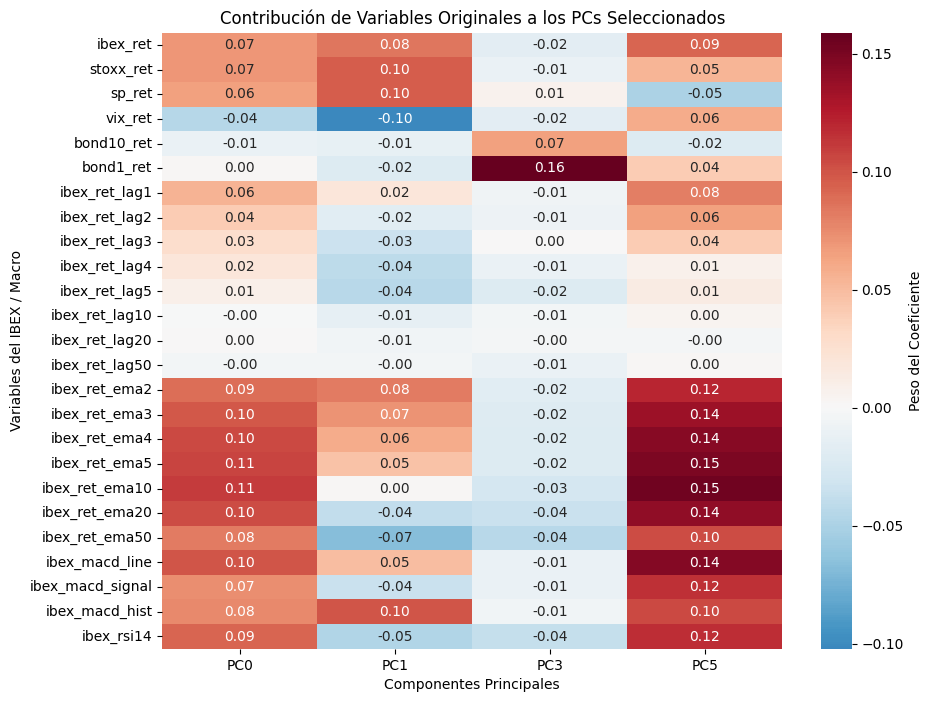

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

# ── 0. CARGA Y PREPARACIÓN DE DATOS ──────────────────────────────────────
file_path = '/content/ibex_tfg_weekly.csv'
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    target_col = df.columns[-1]

    X_num = df.select_dtypes(include=[np.number]).drop(columns=[target_col] if target_col in df.columns else [])
    if 'date' in X_num.columns: X_num = X_num.drop(columns=['date'])
    print(f" Dataset listo para PCA. Dimensiones: {X_num.shape}")
else:
    print(" Error: No se encontró el archivo ibex_tfg_weekly.csv.")

# ── 1. AJUSTE DE PCA (ANÁLISIS GLOBAL) ───────────────────────────────────
sc = StandardScaler()
X_num_s = sc.fit_transform(X_num)

pca = PCA()
pca.fit(X_num_s)

# ── 2. TABLA DE VARIANZA EXPLICADA (REQUERIMIENTO 2.2) ───────────────────
varianza_df = pd.DataFrame({
    'Componente': [f'PC{i}' for i in range(len(pca.explained_variance_ratio_))],
    'Varianza Explicada (%)': pca.explained_variance_ratio_ * 100,
    'Varianza Acumulada (%)': np.cumsum(pca.explained_variance_ratio_) * 100
})

print("\n--- ANÁLISIS DE VARIANZA EXPLICADA ---")
display(varianza_df.head(15).round(2))

# ── 3. ANÁLISIS DE CONTRIBUCIÓN (LOADINGS) ───────────────────────────────

selected_indices = [0, 1, 3, 5]
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i}' for i in range(pca.n_components_)],
    index=X_num.columns
)

print("\n--- VARIABLES DOMINANTES POR COMPONENTE ---")
for idx in selected_indices:
    pc_name = f'PC{idx}'

    top_10 = loadings[pc_name].abs().sort_values(ascending=False).head(10).index
    print(f"\nTop 10 en {pc_name}:")
    display(loadings.loc[top_10, [pc_name]].round(4))

# ── 4. MAPA DE CALOR DE LAS CARGAS ───────────────────────────────────────
plt.figure(figsize=(10, 8))

sns.heatmap(
    loadings.iloc[:25, selected_indices],
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt=".2f",
    cbar_kws={'label': 'Peso del Coeficiente'}
)
plt.title('Contribución de Variables Originales a los PCs Seleccionados')
plt.xlabel('Componentes Principales')
plt.ylabel('Variables del IBEX / Macro')
plt.show()

Iniciando validación detallada (6 folds) con fechas para XGBoost ganadora...


,Fold,Inicio,Fin,Acc_Global (%),Recall_Baja (%),Recall_Sube (%),Kappa,RMSE,R2
0,1,2014-08-01,2016-06-17,55.56,32.00,79.59,0.12,0.0331,-0.18
1,2,2016-06-24,2018-05-11,47.47,41.86,51.79,-0.06,0.0223,-0.12
2,3,2018-05-18,2020-04-03,60.61,41.51,82.61,0.23,0.0318,-0.02
3,4,2020-04-10,2022-02-25,60.61,48.94,71.15,0.20,0.0318,0.01
4,5,2022-03-04,2024-02-02,55.56,35.56,72.22,0.08,0.0225,-0.00
5,6,2024-02-09,2025-12-26,62.63,61.76,63.08,0.23,0.0207,-0.01



RESULTADOS DE CONTRASTES ESTADÍSTICOS
1. Test de Pesaran-Timmermann (Capacidad Direccional):
   - Estadístico Z: 3.0073
   - p-valor: 0.0013 (Significativo)

2. Contraste Diebold-Mariano (XGBoost vs Media Histórica):
   - Estadístico DM: -1.2738
   - p-valor: 0.1014 (No significativo)


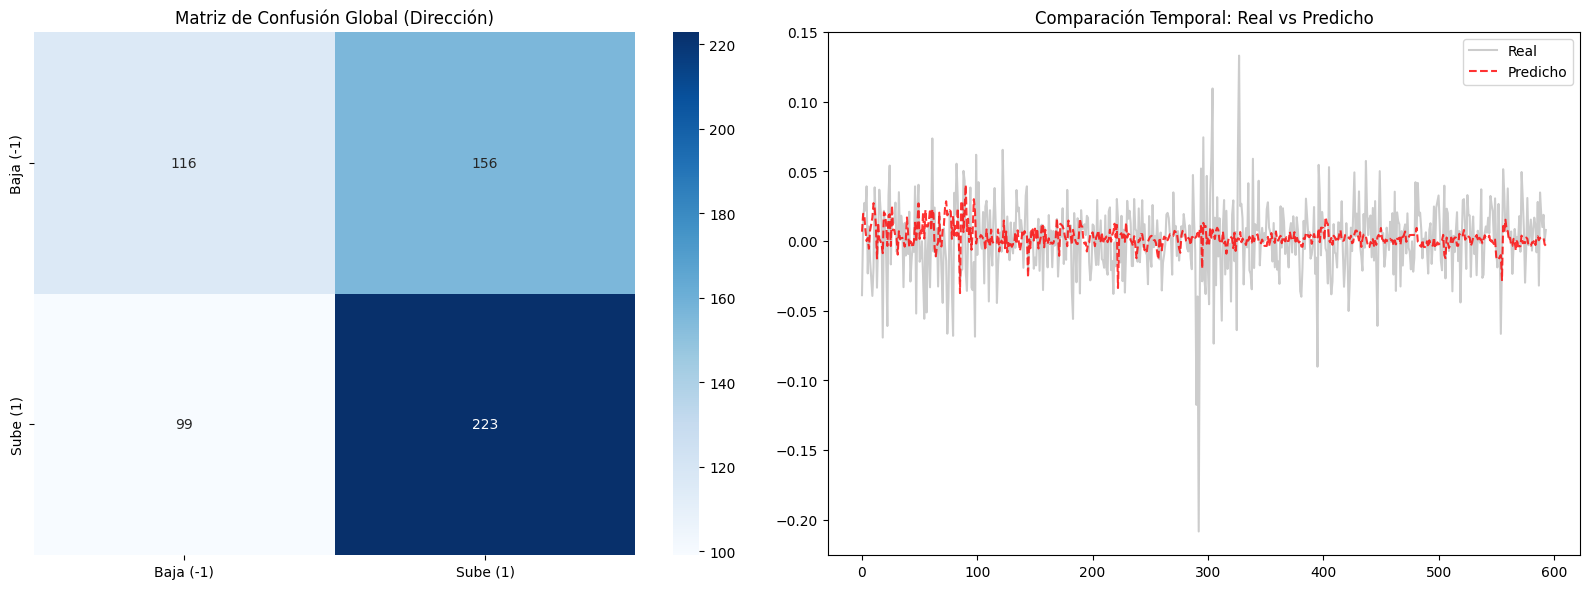


Promedio RMSE: 0.0270
Promedio R2: -0.0533
Promedio Accuracy Global: 57.07%
Promedio Recall_Baja: 43.60%
Promedio Recall_Sube: 70.07%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.metrics import (mean_squared_error, r2_score, cohen_kappa_score,
                             confusion_matrix, accuracy_score)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
import warnings

warnings.filterwarnings('ignore')

# ── FUNCIONES DE CONTRASTES ESTADÍSTICOS ─────────────────────────────────

def pesaran_timmermann_test(y_true, y_pred):
    """Calcula el test de Pesaran-Timmermann para capacidad direccional."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n = len(y_true)
    p_hat = (y_true == y_pred).mean() # Hit Rate (Aciertos)
    p_y = (y_true == 1).mean()        # Probabilidad marginal real positiva
    p_x = (y_pred == 1).mean()        # Probabilidad marginal predicha positiva
    p_star = p_y * p_x + (1 - p_y) * (1 - p_x)

    v_p_hat = (p_star * (1 - p_star)) / n
    v_p_y = (2 * p_x - 1)**2 * (p_y * (1 - p_y) / n)
    v_p_x = (2 * p_y - 1)**2 * (p_x * (1 - p_x) / n)

    v_total = v_p_hat - v_p_y - v_p_x
    if v_total <= 0: return 0.0, 1.0

    z_stat = (p_hat - p_star) / np.sqrt(v_total)
    p_value = 1 - norm.cdf(abs(z_stat)) # Test de una cola
    return z_stat, p_value

def diebold_mariano_test(y_true, y_pred, y_benchmark):
    """Contraste DM: compara error del modelo vs Benchmark (Media Histórica)."""
    e_mod = (y_true - y_pred)**2
    e_ben = (y_true - y_benchmark)**2
    d = e_ben - e_mod # Diferencial de pérdida

    d_bar = np.mean(d)
    v_d = np.var(d, ddof=1) / len(d)
    if v_d <= 0: return 0.0, 1.0

    dm_stat = d_bar / np.sqrt(v_d)
    p_value = 1 - norm.cdf(abs(dm_stat)) # Test de una cola
    return dm_stat, p_value

# ── 0. CARGA DE DATOS PARA ASEGURAR VARIABLES ────────────────────────────
# CORRECCIÓN: Se cambia el nombre del archivo al generado en el preprocesamiento
try:
    df = pd.read_csv('/content/ibex_tfg_weekly.csv')
except FileNotFoundError:
    df = pd.read_csv('ibex_tfg_weekly.csv')

date_col = 'date' if 'date' in df.columns else 'Date'
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col)

target_col = df.columns[-1]
X_num = df.select_dtypes(include=[np.number]).drop(columns=[target_col])
y = df[target_col]

# ── 1. CONFIGURACIÓN DE PARÁMETROS ───────────────────────────────────────
best_xgb_params = {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 3, 'random_state': 42}
best_pca_set = [0, 1, 3, 5]
best_winsor = (0.025, 0.025)

# ── 2. CONFIGURACIÓN DE 6 FOLDS Y CONTENEDORES ───────────────────────────
tscv_6 = TimeSeriesSplit(n_splits=6)
all_preds = []
all_actuals = []
all_benchmarks = [] # Para Diebold-Mariano
fold_detailed_results = []

print(f"Iniciando validación detallada (6 folds) con fechas para XGBoost ganadora...")

for i, (train_idx, test_idx) in enumerate(tscv_6.split(X_num)):
    X_tr, X_te = X_num.iloc[train_idx].copy(), X_num.iloc[test_idx].copy()
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # Benchmark: Media histórica del conjunto de entrenamiento
    mean_benchmark = y_tr.mean()

    # Preprocesamiento
    for col in X_tr.columns:
        l = X_tr[col].quantile(best_winsor[0])
        u = X_tr[col].quantile(1 - best_winsor[1])
        X_tr[col], X_te[col] = X_tr[col].clip(l, u), X_te[col].clip(l, u)

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    pca = PCA(n_components=max(best_pca_set) + 1)
    X_tr_p = pca.fit_transform(X_tr_s)
    X_te_p = pca.transform(X_te_s)

    model = XGBRegressor(**best_xgb_params)
    model.fit(X_tr_p[:, best_pca_set], y_tr)
    preds = model.predict(X_te_p[:, best_pca_set])

    all_preds.extend(preds)
    all_actuals.extend(y_te.values)
    all_benchmarks.extend([mean_benchmark] * len(y_te))

    # Criterio de Signo Unificado (Tratamiento del Cero como Positivo >= 0)
    y_te_sign = np.where(y_te.values >= 0, 1, -1)
    preds_sign = np.where(preds >= 0, 1, -1)

    cm = confusion_matrix(y_te_sign, preds_sign, labels=[-1, 1])
    recall_down = cm[0,0] / cm[0,:].sum() if cm[0,:].sum() > 0 else 0
    recall_up = cm[1,1] / cm[1,:].sum() if cm[1,:].sum() > 0 else 0

    fold_detailed_results.append({
        'Fold': i + 1,
        'Inicio': df[date_col].iloc[test_idx[0]].date(),
        'Fin': df[date_col].iloc[test_idx[-1]].date(),
        'Acc_Global (%)': round(accuracy_score(y_te_sign, preds_sign) * 100, 2),
        'Recall_Baja (%)': round(recall_down * 100, 2),
        'Recall_Sube (%)': round(recall_up * 100, 2),
        'Kappa': round(cohen_kappa_score(y_te_sign, preds_sign), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_te, preds)), 4),
        'R2': round(r2_score(y_te, preds), 2)
    })

summary_detailed_df = pd.DataFrame(fold_detailed_results)
display(summary_detailed_df)

# ── 3. ANÁLISIS ESTADÍSTICO DE SIGNIFICACIÓN ─────────────────────────────
y_act = np.array(all_actuals)
y_pre = np.array(all_preds)
y_ben = np.array(all_benchmarks)

# Signos globales (0 es positivo)
s_act = np.where(y_act >= 0, 1, -1)
s_pre = np.where(y_pre >= 0, 1, -1)

# Test de Pesaran-Timmermann
z_pt, p_pt = pesaran_timmermann_test(s_act, s_pre)

# Test de Diebold-Mariano (Modelo vs Media Histórica)
dm_stat, p_dm = diebold_mariano_test(y_act, y_pre, y_ben)

print("\n" + "="*50)
print("RESULTADOS DE CONTRASTES ESTADÍSTICOS")
print("="*50)
print(f"1. Test de Pesaran-Timmermann (Capacidad Direccional):")
print(f"   - Estadístico Z: {z_pt:.4f}")
print(f"   - p-valor: {p_pt:.4f} " + ("(Significativo)" if p_pt < 0.05 else "(No significativo)"))

print(f"\n2. Contraste Diebold-Mariano (XGBoost vs Media Histórica):")
print(f"   - Estadístico DM: {dm_stat:.4f}")
print(f"   - p-valor: {p_dm:.4f} " + ("(Significativo)" if p_dm < 0.05 else "(No significativo)"))
print("="*50)

# ── 4. VISUALIZACIONES GLOBALES ──────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cm_total = confusion_matrix(s_act, s_pre, labels=[-1, 1])
sns.heatmap(cm_total, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baja (-1)', 'Sube (1)'], yticklabels=['Baja (-1)', 'Sube (1)'], ax=ax[0])
ax[0].set_title('Matriz de Confusión Global (Dirección)')

ax[1].plot(all_actuals, label='Real', alpha=0.4, color='gray')
ax[1].plot(all_preds, label='Predicho', alpha=0.8, color='red', linestyle='--')
ax[1].set_title(f'Comparación Temporal: Real vs Predicho')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"\nPromedio RMSE: {summary_detailed_df['RMSE'].mean():.4f}")
print(f"Promedio R2: {summary_detailed_df['R2'].mean():.4f}")
print(f"Promedio Accuracy Global: {summary_detailed_df['Acc_Global (%)'].mean():.2f}%")
print(f"Promedio Recall_Baja: {summary_detailed_df['Recall_Baja (%)'].mean():.2f}%")
print(f"Promedio Recall_Sube: {summary_detailed_df['Recall_Sube (%)'].mean():.2f}%")

Iniciando validación detallada (6 folds) para Random Forest...


,Fold,Inicio,Fin,Acc_Global (%),Recall_Baja (%),Recall_Sube (%),Kappa,RMSE,R2
0,1,2014-08-01,2016-06-17,55.56,26.00,85.71,0.12,0.0325,-0.14
1,2,2016-06-24,2018-05-11,50.51,39.53,58.93,-0.02,0.0222,-0.11
2,3,2018-05-18,2020-04-03,53.54,32.08,78.26,0.10,0.0318,-0.02
3,4,2020-04-10,2022-02-25,57.58,38.30,75.00,0.14,0.0318,0.01
4,5,2022-03-04,2024-02-02,54.55,40.00,66.67,0.07,0.0228,-0.03
5,6,2024-02-09,2025-12-26,62.63,61.76,63.08,0.23,0.0208,-0.02



RESULTADOS DE CONTRASTES ESTADÍSTICOS (RF)
1. Test de Pesaran-Timmermann (Capacidad Direccional):
   - Estadístico Z: 2.2465
   - p-valor: 0.0123 (Significativo)

2. Contraste Diebold-Mariano (RF vs Media Histórica):
   - Estadístico DM: -1.2777
   - p-valor: 0.1007 (No significativo)


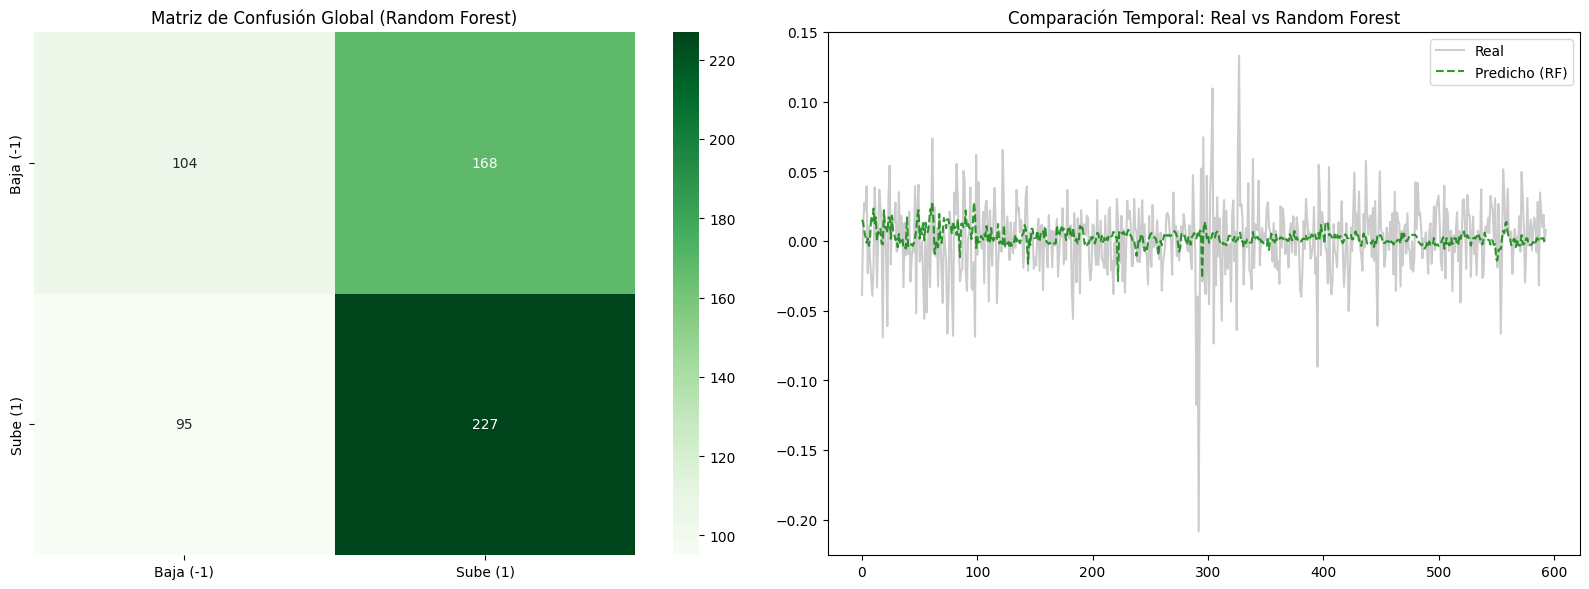


Promedio RMSE: 0.0270
Promedio R2: -0.0517
Promedio Accuracy Global: 55.73%
Promedio Recall_Baja: 39.61%
Promedio Recall_Sube: 71.27%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.metrics import (mean_squared_error, r2_score, cohen_kappa_score,
                             confusion_matrix, accuracy_score)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
import warnings

warnings.filterwarnings('ignore')

# ── FUNCIONES DE CONTRASTES ESTADÍSTICOS ─────────────────────────────────

def pesaran_timmermann_test(y_true, y_pred):
    """Calcula el test de Pesaran-Timmermann para capacidad direccional."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n = len(y_true)
    p_hat = (y_true == y_pred).mean() # Hit Rate
    p_y = (y_true == 1).mean()        # Probabilidad marginal real (+)
    p_x = (y_pred == 1).mean()        # Probabilidad marginal predicha (+)
    p_star = p_y * p_x + (1 - p_y) * (1 - p_x)

    v_p_hat = (p_star * (1 - p_star)) / n
    v_p_y = (2 * p_x - 1)**2 * (p_y * (1 - p_y) / n)
    v_p_x = (2 * p_y - 1)**2 * (p_x * (1 - p_x) / n)

    v_total = v_p_hat - v_p_y - v_p_x
    if v_total <= 0: return 0.0, 1.0

    z_stat = (p_hat - p_star) / np.sqrt(v_total)
    p_value = 1 - norm.cdf(abs(z_stat))
    return z_stat, p_value

def diebold_mariano_test(y_true, y_pred, y_benchmark):
    """Contraste DM: compara error del modelo vs Benchmark (Media Histórica)."""
    e_mod = (y_true - y_pred)**2
    e_ben = (y_true - y_benchmark)**2
    d = e_ben - e_mod

    d_bar = np.mean(d)
    v_d = np.var(d, ddof=1) / len(d)
    if v_d <= 0: return 0.0, 1.0

    dm_stat = d_bar / np.sqrt(v_d)
    p_value = 1 - norm.cdf(abs(dm_stat))
    return dm_stat, p_value

# ── 0. CARGA DE DATOS ────────────────────────────────────────────────────
try:
    df = pd.read_csv('/content/ibex_tfg_weekly.csv')
except FileNotFoundError:
    df = pd.read_csv('ibex_tfg_weekly.csv')

date_col = 'date' if 'date' in df.columns else 'Date'
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col)

target_col = df.columns[-1]
X_num = df.select_dtypes(include=[np.number]).drop(columns=[target_col])
y = df[target_col]

# ── 1. CONFIGURACIÓN DE PARÁMETROS (RANDOM FOREST) ───────────────────────
best_rf_params = {'n_estimators': 200, 'max_depth': 4, 'random_state': 42}
best_pca_set = [0, 1, 3, 5]
best_winsor = (0.025, 0.025)

# ── 2. CONFIGURACIÓN DE 6 FOLDS Y CONTENEDORES ───────────────────────────
tscv_6 = TimeSeriesSplit(n_splits=6)
all_preds, all_actuals, all_benchmarks = [], [], []
fold_detailed_results = []

print(f"Iniciando validación detallada (6 folds) para Random Forest...")

for i, (train_idx, test_idx) in enumerate(tscv_6.split(X_num)):
    X_tr, X_te = X_num.iloc[train_idx].copy(), X_num.iloc[test_idx].copy()
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # Benchmark: Media histórica del entrenamiento (Naive)
    mean_benchmark = y_tr.mean()

    # Preprocesamiento Anti-leakage
    for col in X_tr.columns:
        l = X_tr[col].quantile(best_winsor[0])
        u = X_tr[col].quantile(1 - best_winsor[1])
        X_tr[col], X_te[col] = X_tr[col].clip(l, u), X_te[col].clip(l, u)

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    pca = PCA(n_components=max(best_pca_set) + 1)
    X_tr_p = pca.fit_transform(X_tr_s)
    X_te_p = pca.transform(X_te_s)

    # Entrenamiento del modelo
    model = RandomForestRegressor(**best_rf_params)
    model.fit(X_tr_p[:, best_pca_set], y_tr)
    preds = model.predict(X_te_p[:, best_pca_set])

    all_preds.extend(preds)
    all_actuals.extend(y_te.values)
    all_benchmarks.extend([mean_benchmark] * len(y_te))

    # Criterio de Signo Homogéneo (>= 0 es Positivo)
    y_te_sign = np.where(y_te.values >= 0, 1, -1)
    preds_sign = np.where(preds >= 0, 1, -1)

    cm = confusion_matrix(y_te_sign, preds_sign, labels=[-1, 1])
    recall_down = cm[0,0] / cm[0,:].sum() if cm[0,:].sum() > 0 else 0
    recall_up = cm[1,1] / cm[1,:].sum() if cm[1,:].sum() > 0 else 0

    fold_detailed_results.append({
        'Fold': i + 1,
        'Inicio': df[date_col].iloc[test_idx[0]].date(),
        'Fin': df[date_col].iloc[test_idx[-1]].date(),
        'Acc_Global (%)': round(accuracy_score(y_te_sign, preds_sign) * 100, 2),
        'Recall_Baja (%)': round(recall_down * 100, 2),
        'Recall_Sube (%)': round(recall_up * 100, 2),
        'Kappa': round(cohen_kappa_score(y_te_sign, preds_sign), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_te, preds)), 4),
        'R2': round(r2_score(y_te, preds), 2)
    })

summary_detailed_df = pd.DataFrame(fold_detailed_results)
display(summary_detailed_df)

# ── 3. ANÁLISIS ESTADÍSTICO DE SIGNIFICACIÓN ─────────────────────────────
y_act, y_pre, y_ben = np.array(all_actuals), np.array(all_preds), np.array(all_benchmarks)
s_act, s_pre = np.where(y_act >= 0, 1, -1), np.where(y_pre >= 0, 1, -1)

z_pt, p_pt = pesaran_timmermann_test(s_act, s_pre)
dm_stat, p_dm = diebold_mariano_test(y_act, y_pre, y_ben)

print("\n" + "="*50)
print("RESULTADOS DE CONTRASTES ESTADÍSTICOS (RF)")
print("="*50)
print(f"1. Test de Pesaran-Timmermann (Capacidad Direccional):")
print(f"   - Estadístico Z: {z_pt:.4f}")
print(f"   - p-valor: {p_pt:.4f} " + ("(Significativo)" if p_pt < 0.05 else "(No significativo)"))

print(f"\n2. Contraste Diebold-Mariano (RF vs Media Histórica):")
print(f"   - Estadístico DM: {dm_stat:.4f}")
print(f"   - p-valor: {p_dm:.4f} " + ("(Significativo)" if p_dm < 0.05 else "(No significativo)"))
print("="*50)

# ── 4. VISUALIZACIONES GLOBALES ──────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cm_total = confusion_matrix(s_act, s_pre, labels=[-1, 1])
sns.heatmap(cm_total, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Baja (-1)', 'Sube (1)'], yticklabels=['Baja (-1)', 'Sube (1)'], ax=ax[0])
ax[0].set_title('Matriz de Confusión Global (Random Forest)')

ax[1].plot(all_actuals, label='Real', alpha=0.4, color='gray')
ax[1].plot(all_preds, label='Predicho (RF)', alpha=0.8, color='green', linestyle='--')
ax[1].set_title('Comparación Temporal: Real vs Random Forest')
ax[1].legend()
plt.tight_layout()
plt.show()

# ── 5. RESUMEN FINAL DE MÉTRICAS (PROMEDIOS) ─────────────────────────────
print(f"\nPromedio RMSE: {summary_detailed_df['RMSE'].mean():.4f}")
print(f"Promedio R2: {summary_detailed_df['R2'].mean():.4f}")
print(f"Promedio Accuracy Global: {summary_detailed_df['Acc_Global (%)'].mean():.2f}%")
print(f"Promedio Recall_Baja: {summary_detailed_df['Recall_Baja (%)'].mean():.2f}%")
print(f"Promedio Recall_Sube: {summary_detailed_df['Recall_Sube (%)'].mean():.2f}%")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import ElasticNet
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings('ignore')

# ── 1. CARGA Y PREPARACIÓN DE DATOS ──────────────────────────────────────
try:
    df = pd.read_csv('/content/ibex_tfg_weekly.csv')
except FileNotFoundError:
    raise FileNotFoundError("No se encuentra el archivo 'ibex_tfg_weekly.csv'.")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

target_col = df.columns[-1]
y = df[target_col]
# Seleccionamos solo las variables numéricas para el entrenamiento
X_num = df.drop(columns=[target_col, 'date']).select_dtypes(include=[np.number])

print(f"Target: {target_col}")
print("Modelo: Elastic Net (Incluyendo todos los años en el entrenamiento)")

# ── 2. DEFINICIÓN DEL EXPERIMENTO EXHAUSTIVO ─────────────────────────────
def run_exhaustive_elastic_net():
    # Parámetros de búsqueda (mismos que la referencia)
    winsor_limits = [(0.01, 0.01), (0.025, 0.025), (0.05, 0.05)]
    pca_sets = [
        [0], [0, 1], [0, 2], [0, 3], [0, 4],
        [0, 1, 2], [0, 1, 3], [0, 1, 4],
        [0, 1, 2, 3], [0, 1, 3, 5], [0, 1, 3, 7],
        [0, 1, 2, 3, 4, 5]
    ]

    # Hiperparámetros de Elastic Net
    elastic_params = [
        {'alpha': 0.01, 'l1_ratio': 0.2, 'random_state': 42},
        {'alpha': 0.01, 'l1_ratio': 0.5, 'random_state': 42},
        {'alpha': 0.01, 'l1_ratio': 0.8, 'random_state': 42},
        {'alpha': 0.1, 'l1_ratio': 0.5, 'random_state': 42}
    ]

    tscv = TimeSeriesSplit(n_splits=5)
    results = []

    for w_lim in winsor_limits:
        for pca_set in pca_sets:
            for params in elastic_params:
                fold_acc = []

                for train_idx, test_idx in tscv.split(X_num):
                    # Separación de datos sin filtrar años
                    X_tr, X_te = X_num.iloc[train_idx].copy(), X_num.iloc[test_idx].copy()
                    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

                    # ── PREPROCESAMIENTO POR FOLD (ANTI-LEAKAGE) ─────────
                    for col in X_tr.columns:
                        l = X_tr[col].quantile(w_lim[0])
                        u = X_tr[col].quantile(1 - w_lim[1])
                        X_tr[col] = X_tr[col].clip(l, u)
                        X_te[col] = X_te[col].clip(l, u)

                    sc = StandardScaler()
                    X_tr_s = sc.fit_transform(X_tr)
                    X_te_s = sc.transform(X_te)

                    pca = PCA(n_components=max(pca_set) + 1)
                    X_tr_p = pca.fit_transform(X_tr_s)
                    X_te_p = pca.transform(X_te_s)

                    # ── ENTRENAMIENTO Y PREDICCIÓN ───────────────────────
                    model = ElasticNet(**params)
                    model.fit(X_tr_p[:, pca_set], y_tr)
                    preds_cont = model.predict(X_te_p[:, pca_set])

                    # ── HOMOGENEIZACIÓN DE SIGNO (0 es positivo/subida) ──
                    y_te_sign = np.where(y_te.values >= 0, 1, -1)
                    preds_sign = np.where(preds_cont >= 0, 1, -1)

                    acc = (preds_sign == y_te_sign).mean()
                    fold_acc.append(acc)

                if fold_acc:
                    results.append({
                        'model': 'ElasticNet',
                        'alpha': params['alpha'],
                        'l1_ratio': params['l1_ratio'],
                        'winsor': w_lim,
                        'pca_set': pca_set,
                        'accuracy': np.mean(fold_acc)
                    })

    return pd.DataFrame(results).sort_values('accuracy', ascending=False)

# ── 3. EJECUCIÓN Y TABLA DE RESULTADOS ───────────────────────────────────
full_results = run_exhaustive_elastic_net()
print("\nTop 20 mejores configuraciones (Elastic Net):")
display(full_results.head(20))

Target: TARGET_ibex_ret_fwd1
Modelo: Elastic Net (Incluyendo todos los años en el entrenamiento)

Top 20 mejores configuraciones (Elastic Net):


,model,alpha,l1_ratio,winsor,pca_set,accuracy
133,ElasticNet,0.01,0.5,"(0.05, 0.05)","[0, 1, 3, 5]",0.582759
141,ElasticNet,0.01,0.5,"(0.05, 0.05)","[0, 1, 2, 3, 4, 5]",0.575862
129,ElasticNet,0.01,0.5,"(0.05, 0.05)","[0, 1, 2, 3]",0.570690
121,ElasticNet,0.01,0.5,"(0.05, 0.05)","[0, 1, 3]",0.570690
93,ElasticNet,0.01,0.5,"(0.025, 0.025)","[0, 1, 2, 3, 4, 5]",0.568966
37,ElasticNet,0.01,0.5,"(0.01, 0.01)","[0, 1, 3, 5]",0.567241
45,ElasticNet,0.01,0.5,"(0.01, 0.01)","[0, 1, 2, 3, 4, 5]",0.567241
101,ElasticNet,0.01,0.5,"(0.05, 0.05)","[0, 1]",0.567241
117,ElasticNet,0.01,0.5,"(0.05, 0.05)","[0, 1, 2]",0.567241
13,ElasticNet,0.01,0.5,"(0.01, 0.01)","[0, 3]",0.565517


Iniciando validación detallada (6 folds) para Elastic Net...


,Fold,Inicio,Fin,Acc_Global (%),Recall_Baja (%),Recall_Sube (%),Kappa,RMSE,R2
0,1,2014-08-01,2016-06-17,50.51,8.00,93.88,0.02,0.0326,-0.14
1,2,2016-06-24,2018-05-11,55.56,30.23,75.00,0.05,0.0214,-0.03
2,3,2018-05-18,2020-04-03,51.52,16.98,91.30,0.08,0.0320,-0.03
3,4,2020-04-10,2022-02-25,52.53,0.00,100.00,0.00,0.0320,0.00
4,5,2022-03-04,2024-02-02,56.57,28.89,79.63,0.09,0.0226,-0.00
5,6,2024-02-09,2025-12-26,63.64,23.53,84.62,0.09,0.0212,-0.05



RESULTADOS DE CONTRASTES ESTADÍSTICOS (ELASTIC NET)
1. Test de Pesaran-Timmermann (Capacidad Direccional):
   - Estadístico Z: 1.4412
   - p-valor: 0.0748 (No significativo)

2. Contraste Diebold-Mariano (EN vs Media Histórica):
   - Estadístico DM: -1.7953
   - p-valor: 0.0363 (Significativo)


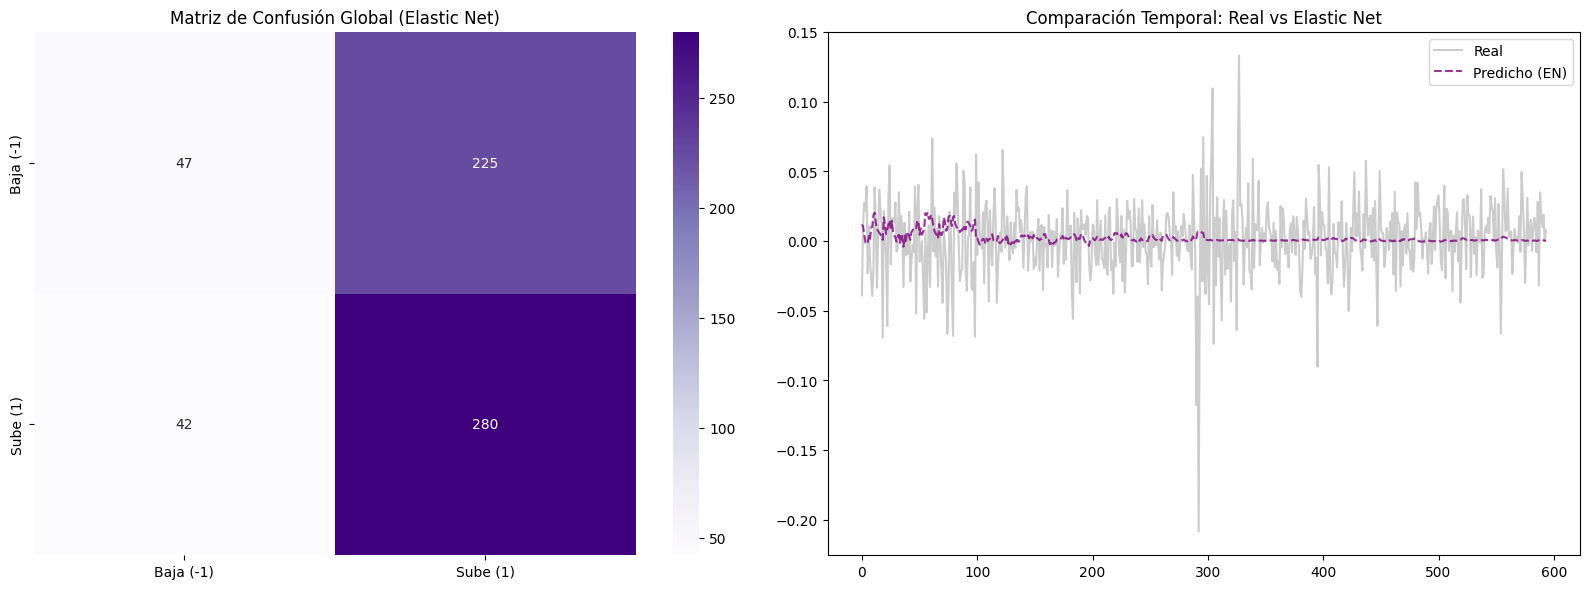


Promedio RMSE: 0.0270
Promedio R2: -0.0417
Promedio Accuracy Global: 55.05%
Promedio Recall_Baja: 17.94%
Promedio Recall_Sube: 87.41%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.metrics import (mean_squared_error, r2_score, cohen_kappa_score,
                             confusion_matrix, accuracy_score)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet
import warnings

warnings.filterwarnings('ignore')

# ── FUNCIONES DE CONTRASTES ESTADÍSTICOS ─────────────────────────────────

def pesaran_timmermann_test(y_true, y_pred):
    """Calcula el test de Pesaran-Timmermann para capacidad direccional."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n = len(y_true)
    p_hat = (y_true == y_pred).mean() # Hit Rate
    p_y = (y_true == 1).mean()        # Probabilidad marginal real (+)
    p_x = (y_pred == 1).mean()        # Probabilidad marginal predicha (+)
    p_star = p_y * p_x + (1 - p_y) * (1 - p_x)

    v_p_hat = (p_star * (1 - p_star)) / n
    v_p_y = (2 * p_x - 1)**2 * (p_y * (1 - p_y) / n)
    v_p_x = (2 * p_y - 1)**2 * (p_x * (1 - p_x) / n)

    v_total = v_p_hat - v_p_y - v_p_x
    if v_total <= 0: return 0.0, 1.0

    z_stat = (p_hat - p_star) / np.sqrt(v_total)
    p_value = 1 - norm.cdf(abs(z_stat))
    return z_stat, p_value

def diebold_mariano_test(y_true, y_pred, y_benchmark):
    """Contraste DM: compara error del modelo vs Benchmark (Media Histórica)."""
    e_mod = (y_true - y_pred)**2
    e_ben = (y_true - y_benchmark)**2
    d = e_ben - e_mod

    d_bar = np.mean(d)
    v_d = np.var(d, ddof=1) / len(d)
    if v_d <= 0: return 0.0, 1.0

    dm_stat = d_bar / np.sqrt(v_d)
    p_value = 1 - norm.cdf(abs(dm_stat))
    return dm_stat, p_value

# ── 0. CARGA DE DATOS ────────────────────────────────────────────────────
try:
    df = pd.read_csv('/content/ibex_tfg_weekly.csv')
except FileNotFoundError:
    df = pd.read_csv('ibex_tfg_weekly.csv')

date_col = 'date' if 'date' in df.columns else 'Date'
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col)

target_col = df.columns[-1]
X_num = df.select_dtypes(include=[np.number]).drop(columns=[target_col])
y = df[target_col]

# ── 1. CONFIGURACIÓN DE PARÁMETROS (ELASTIC NET GANADORA) ────────────────
best_elastic_params = {'alpha': 0.01, 'l1_ratio': 0.5, 'random_state': 42}
best_pca_set = [0, 1, 3, 5]
best_winsor = (0.05, 0.05)

# ── 2. CONFIGURACIÓN DE 6 FOLDS Y CONTENEDORES ───────────────────────────
tscv_6 = TimeSeriesSplit(n_splits=6)
all_preds, all_actuals, all_benchmarks = [], [], []
fold_detailed_results = []

print(f"Iniciando validación detallada (6 folds) para Elastic Net...")

for i, (train_idx, test_idx) in enumerate(tscv_6.split(X_num)):
    X_tr, X_te = X_num.iloc[train_idx].copy(), X_num.iloc[test_idx].copy()
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # Benchmark: Media histórica del entrenamiento
    mean_benchmark = y_tr.mean()

    # Preprocesamiento Anti-leakage
    for col in X_tr.columns:
        l = X_tr[col].quantile(best_winsor[0])
        u = X_tr[col].quantile(1 - best_winsor[1])
        X_tr[col], X_te[col] = X_tr[col].clip(l, u), X_te[col].clip(l, u)

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    pca = PCA(n_components=max(best_pca_set) + 1)
    X_tr_p = pca.fit_transform(X_tr_s)
    X_te_p = pca.transform(X_te_s)

    # Entrenamiento del modelo Elastic Net
    model = ElasticNet(**best_elastic_params)
    model.fit(X_tr_p[:, best_pca_set], y_tr)
    preds = model.predict(X_te_p[:, best_pca_set])

    all_preds.extend(preds)
    all_actuals.extend(y_te.values)
    all_benchmarks.extend([mean_benchmark] * len(y_te))

    # Criterio de Signo Homogéneo (>= 0 es Positivo)
    y_te_sign = np.where(y_te.values >= 0, 1, -1)
    preds_sign = np.where(preds >= 0, 1, -1)

    cm = confusion_matrix(y_te_sign, preds_sign, labels=[-1, 1])
    recall_down = cm[0,0] / cm[0,:].sum() if cm[0,:].sum() > 0 else 0
    recall_up = cm[1,1] / cm[1,:].sum() if cm[1,:].sum() > 0 else 0

    fold_detailed_results.append({
        'Fold': i + 1,
        'Inicio': df[date_col].iloc[test_idx[0]].date(),
        'Fin': df[date_col].iloc[test_idx[-1]].date(),
        'Acc_Global (%)': round(accuracy_score(y_te_sign, preds_sign) * 100, 2),
        'Recall_Baja (%)': round(recall_down * 100, 2),
        'Recall_Sube (%)': round(recall_up * 100, 2),
        'Kappa': round(cohen_kappa_score(y_te_sign, preds_sign), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_te, preds)), 4),
        'R2': round(r2_score(y_te, preds), 2)
    })

summary_detailed_df = pd.DataFrame(fold_detailed_results)
display(summary_detailed_df)

# ── 3. ANÁLISIS ESTADÍSTICO DE SIGNIFICACIÓN ─────────────────────────────
y_act, y_pre, y_ben = np.array(all_actuals), np.array(all_preds), np.array(all_benchmarks)
s_act, s_pre = np.where(y_act >= 0, 1, -1), np.where(y_pre >= 0, 1, -1)

z_pt, p_pt = pesaran_timmermann_test(s_act, s_pre)
dm_stat, p_dm = diebold_mariano_test(y_act, y_pre, y_ben)

print("\n" + "="*50)
print("RESULTADOS DE CONTRASTES ESTADÍSTICOS (ELASTIC NET)")
print("="*50)
print(f"1. Test de Pesaran-Timmermann (Capacidad Direccional):")
print(f"   - Estadístico Z: {z_pt:.4f}")
print(f"   - p-valor: {p_pt:.4f} " + ("(Significativo)" if p_pt < 0.05 else "(No significativo)"))

print(f"\n2. Contraste Diebold-Mariano (EN vs Media Histórica):")
print(f"   - Estadístico DM: {dm_stat:.4f}")
print(f"   - p-valor: {p_dm:.4f} " + ("(Significativo)" if p_dm < 0.05 else "(No significativo)"))
print("="*50)

# ── 4. VISUALIZACIONES GLOBALES ──────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cm_total = confusion_matrix(s_act, s_pre, labels=[-1, 1])
sns.heatmap(cm_total, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Baja (-1)', 'Sube (1)'], yticklabels=['Baja (-1)', 'Sube (1)'], ax=ax[0])
ax[0].set_title('Matriz de Confusión Global (Elastic Net)')

ax[1].plot(all_actuals, label='Real', alpha=0.4, color='gray')
ax[1].plot(all_preds, label='Predicho (EN)', alpha=0.8, color='purple', linestyle='--')
ax[1].set_title('Comparación Temporal: Real vs Elastic Net')
ax[1].legend()
plt.tight_layout()
plt.show()

# ── 5. RESUMEN FINAL DE MÉTRICAS (PROMEDIOS) ─────────────────────────────
print(f"\nPromedio RMSE: {summary_detailed_df['RMSE'].mean():.4f}")
print(f"Promedio R2: {summary_detailed_df['R2'].mean():.4f}")
print(f"Promedio Accuracy Global: {summary_detailed_df['Acc_Global (%)'].mean():.2f}%")
print(f"Promedio Recall_Baja: {summary_detailed_df['Recall_Baja (%)'].mean():.2f}%")
print(f"Promedio Recall_Sube: {summary_detailed_df['Recall_Sube (%)'].mean():.2f}%")

In [ ]:
import itertools
import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')

# 1. CARGA DE DATOS Y DEFINICIÓN DE 'y'
try:
    df = pd.read_csv('/content/ibex_tfg_weekly.csv')
    target_col = df.columns[-1]
    y = df[target_col].dropna()
    print(f"Variable 'y' cargada correctamente. Target: {target_col}")

    # 2. DEFINIR COMBINACIONES (d=0 fijo)
    p_vals = [0, 1, 2]
    q_vals = [0, 1, 2]
    pdq_combos = [(p, 0, q) for p in p_vals for q in q_vals]

    # Mantenemos 5 SPLITS como has pedido
    tscv = TimeSeriesSplit(n_splits=5)
    grid_results = []

    print(f'--- COMPARATIVA GLOBAL ARIMA ---')

    for pdq in pdq_combos:
        fold_accs = []
        fold_up_accs = []
        fold_down_accs = []

        for train_index, test_index in tscv.split(y):
            y_train = y.iloc[train_index].values
            y_test = y.iloc[test_index].values

            history = list(y_train)
            predictions = []

            try:
                for t in range(len(y_test)):
                    model_fit = ARIMA(history, order=pdq).fit()
                    yhat = model_fit.forecast()[0]
                    predictions.append(yhat)
                    history.append(y_test[t])

                # VERIFICACIÓN: Homogeneización del signo (>= 0 es 1)
                # Esto asegura que el 0 se trate igual que en XGBoost/RF
                y_test_bin = np.where(y_test >= 0, 1, 0)
                preds_bin = np.where(np.array(predictions) >= 0, 1, 0)

                # Accuracy General
                acc = accuracy_score(y_test_bin, preds_bin)
                fold_accs.append(acc)

                # Accuracy en Subidas (Real es 1)
                mask_up = (y_test_bin == 1)
                if np.any(mask_up):
                    fold_up_accs.append(accuracy_score(y_test_bin[mask_up], preds_bin[mask_up]))

                # Accuracy en Bajadas (Real es 0)
                mask_down = (y_test_bin == 0)
                if np.any(mask_down):
                    fold_down_accs.append(accuracy_score(y_test_bin[mask_down], preds_bin[mask_down]))

            except:
                continue

        if fold_accs:
            avg_acc = np.mean(fold_accs)
            avg_up = np.mean(fold_up_accs) if fold_up_accs else 0
            avg_down = np.mean(fold_down_accs) if fold_down_accs else 0

            print(f'ARIMA{pdq} | Acc: {avg_acc:.4f} | Up: {avg_up:.4f} | Down: {avg_down:.4f}')
            grid_results.append({
                'Config': f'ARIMA{pdq}',
                'Avg_Accuracy': avg_acc,
                'Acc_Subidas': avg_up,
                'Acc_Bajadas': avg_down
            })

    # 3. RANKING FINAL
    results_df = pd.DataFrame(grid_results).sort_values(by='Avg_Accuracy', ascending=False)
    display(results_df)

except Exception as e:
    print(f"Error al procesar: {e}")

Variable 'y' cargada correctamente. Target: TARGET_ibex_ret_fwd1
--- COMPARATIVA GLOBAL ARIMA ---
ARIMA(0, 0, 0) | Acc: 0.5431 | Up: 1.0000 | Down: 0.0000
ARIMA(0, 0, 1) | Acc: 0.5328 | Up: 0.9499 | Down: 0.0333
ARIMA(0, 0, 2) | Acc: 0.5155 | Up: 0.7655 | Down: 0.2082
ARIMA(1, 0, 0) | Acc: 0.5293 | Up: 0.9499 | Down: 0.0249
ARIMA(1, 0, 1) | Acc: 0.5207 | Up: 0.8286 | Down: 0.1668
ARIMA(1, 0, 2) | Acc: 0.4931 | Up: 0.5589 | Down: 0.4499
ARIMA(2, 0, 0) | Acc: 0.5155 | Up: 0.7582 | Down: 0.2144
ARIMA(2, 0, 1) | Acc: 0.4948 | Up: 0.6379 | Down: 0.3296
ARIMA(2, 0, 2) | Acc: 0.5259 | Up: 0.6639 | Down: 0.3656


,Config,Avg_Accuracy,Acc_Subidas,Acc_Bajadas
0,"ARIMA(0, 0, 0)",0.543103,1.000000,0.000000
1,"ARIMA(0, 0, 1)",0.532759,0.949885,0.033326
3,"ARIMA(1, 0, 0)",0.529310,0.949885,0.024877
8,"ARIMA(2, 0, 2)",0.525862,0.663896,0.365642
4,"ARIMA(1, 0, 1)",0.520690,0.828608,0.166843
2,"ARIMA(0, 0, 2)",0.515517,0.765467,0.208168
6,"ARIMA(2, 0, 0)",0.515517,0.758248,0.214402
7,"ARIMA(2, 0, 1)",0.494828,0.637881,0.329561
5,"ARIMA(1, 0, 2)",0.493103,0.558878,0.449896


✅ Datos cargados correctamente. Filas: 697

--- EVALUACIÓN SISTEMÁTICA: ARIMA(2, 0, 2) (6 FOLDS) ---
Calculando walk-forward... (Esto puede tardar un poco)

--- DESGLOSE DETALLADO POR FOLD ---


,Fold,Inicio Test,Fin Test,Accuracy,Recall_Baja,Recall_Sube,Kappa,RMSE,R2
0,1,2014-08-01,2016-06-17,55.56%,24.00%,87.76%,0.12,0.0316,-0.08
1,2,2016-06-24,2018-05-11,54.55%,32.56%,71.43%,0.04,0.0214,-0.03
2,3,2018-05-18,2020-04-03,51.52%,35.85%,69.57%,0.05,0.0328,-0.09
3,4,2020-04-10,2022-02-25,41.41%,29.79%,51.92%,-0.18,0.0323,-0.02
4,5,2022-03-04,2024-02-02,53.54%,48.89%,57.41%,0.06,0.0225,-0.00
5,6,2024-02-09,2025-12-26,58.59%,44.12%,66.15%,0.10,0.0212,-0.05



RESULTADOS ESTADÍSTICOS ARIMA(2, 0, 2)
1. Test Pesaran-Timmermann (Capacidad Direccional):
   - Estadístico Z: 0.6087
   - p-valor: 0.2714 (No significativo)

2. Contraste Diebold-Mariano (ARIMA vs Media Histórica):
   - Estadístico DM: -1.5594
   - p-valor: 0.0595 (No significativo)

--- RESUMEN DE MÉTRICAS PROMEDIO (ARIMA (2, 0, 2)) ---


,Métrica,Valor
0,Accuracy Medio,52.53%
1,Recall Baja Medio,35.87%
2,Recall Sube Medio,67.37%
3,Kappa Medio,0.03
4,RMSE Medio,0.0270
5,R2 Medio,-0.05


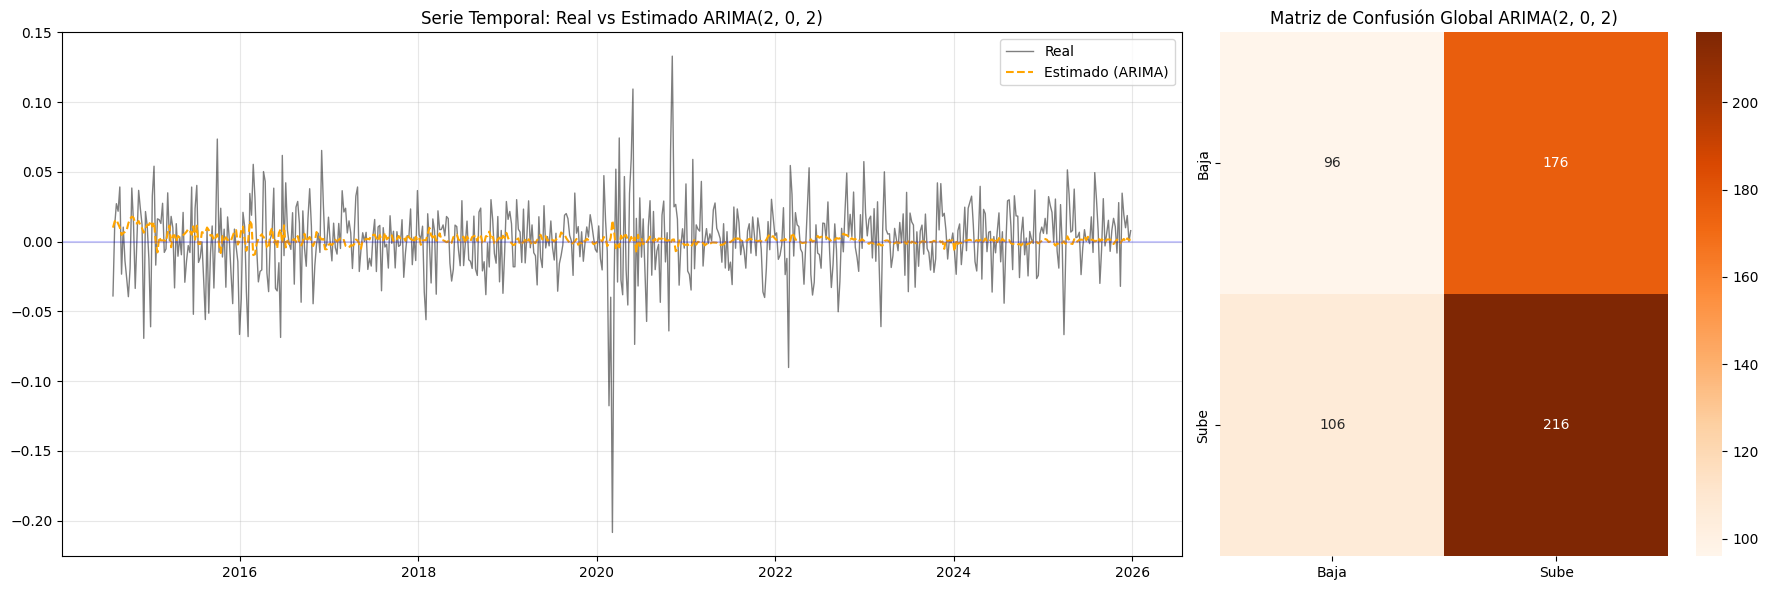

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import norm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (mean_squared_error, r2_score, cohen_kappa_score,
                             confusion_matrix, accuracy_score)
from sklearn.model_selection import TimeSeriesSplit
import warnings
import os

warnings.filterwarnings('ignore')

# ── FUNCIONES DE CONTRASTES ESTADÍSTICOS ─────────────────────────────────

def pesaran_timmermann_test(y_true, y_pred):
    """Calcula el test de Pesaran-Timmermann para capacidad direccional."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n = len(y_true)
    p_hat = (y_true == y_pred).mean()
    p_y = (y_true == 1).mean()
    p_x = (y_pred == 1).mean()
    p_star = p_y * p_x + (1 - p_y) * (1 - p_x)

    v_p_hat = (p_star * (1 - p_star)) / n
    v_p_y = (2 * p_x - 1)**2 * (p_y * (1 - p_y) / n)
    v_p_x = (2 * p_y - 1)**2 * (p_x * (1 - p_x) / n)

    v_total = v_p_hat - v_p_y - v_p_x
    if v_total <= 0: return 0.0, 1.0

    z_stat = (p_hat - p_star) / np.sqrt(v_total)
    p_value = 1 - norm.cdf(abs(z_stat))
    return z_stat, p_value

def diebold_mariano_test(y_true, y_pred, y_benchmark):
    """Contraste DM: compara error del modelo vs Benchmark (Media Histórica)."""
    e_mod = (y_true - y_pred)**2
    e_ben = (y_true - y_benchmark)**2
    d = e_ben - e_mod
    d_bar = np.mean(d)
    v_d = np.var(d, ddof=1) / len(d)
    if v_d <= 0: return 0.0, 1.0

    dm_stat = d_bar / np.sqrt(v_d)
    p_value = 1 - norm.cdf(abs(dm_stat))
    return dm_stat, p_value

# ── 1. CARGA DE DATOS CON VALIDACIÓN ───────────────────────────────────────
file_path = '/content/ibex_tfg_weekly.csv'

if os.path.exists(file_path):
    try:
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()
        date_col = next((c for c in df.columns if c.lower() in ['date', 'fecha']), None)

        if date_col:
            df[date_col] = pd.to_datetime(df[date_col])
            df = df.sort_values(date_col)

        y = df[df.columns[-1]]
        print(f' Datos cargados correctamente. Filas: {len(df)}')

        PDQ_NEW = (2, 0, 2)
        tscv_6 = TimeSeriesSplit(n_splits=6)
        all_preds, all_actuals, all_benchmarks, all_dates = [], [], [], []
        fold_results_list = []

        print(f'\n--- EVALUACIÓN SISTEMÁTICA: ARIMA{PDQ_NEW} (6 FOLDS) ---')
        print("Calculando walk-forward... (Esto puede tardar un poco)\n")

        for i, (train_idx, test_idx) in enumerate(tscv_6.split(y)):
            y_train, y_test = y.iloc[train_idx].values, y.iloc[test_idx].values

            # Benchmark para DM: Media histórica del entrenamiento
            mean_benchmark = np.mean(y_train)

            if date_col:
                test_dates = df[date_col].iloc[test_idx]
                start_test = test_dates.min().strftime('%Y-%m-%d')
                end_test = test_dates.max().strftime('%Y-%m-%d')
                all_dates.extend(test_dates.tolist())
            else:
                start_test, end_test = "N/A", "N/A"
                all_dates.extend(range(len(all_dates), len(all_dates) + len(test_idx)))

            history = list(y_train)
            predictions = []

            for t in range(len(y_test)):
                try:
                    model_fit = ARIMA(history, order=PDQ_NEW).fit()
                    yhat = model_fit.forecast()[0]
                    predictions.append(yhat)
                except:
                    predictions.append(mean_benchmark)
                history.append(y_test[t])

            predictions = np.array(predictions)
            all_preds.extend(predictions)
            all_actuals.extend(y_test)
            all_benchmarks.extend([mean_benchmark] * len(y_test))

            # Métricas del Fold (>= 0 es positivo)
            y_te_bin = np.where(y_test >= 0, 1, -1)
            preds_bin = np.where(predictions >= 0, 1, -1)

            cm = confusion_matrix(y_te_bin, preds_bin, labels=[-1, 1])
            acc = accuracy_score(y_te_bin, preds_bin)
            recall_baja = cm[0,0]/cm[0,:].sum() if cm[0,:].sum() > 0 else 0
            recall_sube = cm[1,1]/cm[1,:].sum() if cm[1,:].sum() > 0 else 0
            kappa = cohen_kappa_score(y_te_bin, preds_bin)
            rmse = np.sqrt(mean_squared_error(y_test, predictions))
            r2 = r2_score(y_test, predictions)

            fold_results_list.append({
                'Fold': i + 1,
                'Inicio Test': start_test,
                'Fin Test': end_test,
                'Accuracy': acc,
                'Recall_Baja': recall_baja,
                'Recall_Sube': recall_sube,
                'Kappa': kappa,
                'RMSE': rmse,
                'R2': r2
            })

        # --- MOSTRAR RESULTADOS DETALLADOS POR FOLD ---
        df_folds = pd.DataFrame(fold_results_list)
        df_folds_display = df_folds.copy()
        for col in ['Accuracy', 'Recall_Baja', 'Recall_Sube']:
            df_folds_display[col] = df_folds_display[col].apply(lambda x: f"{x:.2%}")
        for col in ['Kappa', 'R2']:
            df_folds_display[col] = df_folds_display[col].apply(lambda x: f"{x:.2f}")
        df_folds_display['RMSE'] = df_folds_display['RMSE'].apply(lambda x: f"{x:.4f}")

        print('--- DESGLOSE DETALLADO POR FOLD ---')
        display(df_folds_display)

        # --- ANÁLISIS ESTADÍSTICO DE SIGNIFICACIÓN ---
        y_act, y_pre, y_ben = np.array(all_actuals), np.array(all_preds), np.array(all_benchmarks)
        s_act, s_pre = np.where(y_act >= 0, 1, -1), np.where(y_pre >= 0, 1, -1)

        z_pt, p_pt = pesaran_timmermann_test(s_act, s_pre)
        dm_stat, p_dm = diebold_mariano_test(y_act, y_pre, y_ben)

        print("\n" + "="*50)
        print(f"RESULTADOS ESTADÍSTICOS ARIMA{PDQ_NEW}")
        print("="*50)
        print(f"1. Test Pesaran-Timmermann (Capacidad Direccional):")
        print(f"   - Estadístico Z: {z_pt:.4f}")
        print(f"   - p-valor: {p_pt:.4f} " + ("(Significativo)" if p_pt < 0.05 else "(No significativo)"))

        print(f"\n2. Contraste Diebold-Mariano (ARIMA vs Media Histórica):")
        print(f"   - Estadístico DM: {dm_stat:.4f}")
        print(f"   - p-valor: {p_dm:.4f} " + ("(Significativo)" if p_dm < 0.05 else "(No significativo)"))
        print("="*50)

        # --- RESUMEN PROMEDIO ---
        avg_metrics = pd.DataFrame({
            'Métrica': ['Accuracy Medio', 'Recall Baja Medio', 'Recall Sube Medio', 'Kappa Medio', 'RMSE Medio', 'R2 Medio'],
            'Valor': [f"{df_folds['Accuracy'].mean():.2%}",
                      f"{df_folds['Recall_Baja'].mean():.2%}",
                      f"{df_folds['Recall_Sube'].mean():.2%}",
                      f"{df_folds['Kappa'].mean():.2f}",
                      f"{df_folds['RMSE'].mean():.4f}",
                      f"{df_folds['R2'].mean():.2f}"]
        })
        print(f'\n--- RESUMEN DE MÉTRICAS PROMEDIO (ARIMA {PDQ_NEW}) ---')
        display(avg_metrics)

        # --- GRÁFICAS ---
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [2, 1]})
        ax1.plot(all_dates, all_actuals, label='Real', color='black', alpha=0.5, linewidth=1)
        ax1.plot(all_dates, all_preds, label='Estimado (ARIMA)', color='orange', linestyle='--', linewidth=1.5)
        ax1.axhline(0, color='blue', linestyle='-', alpha=0.2)
        ax1.set_title(f'Serie Temporal: Real vs Estimado ARIMA{PDQ_NEW}')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        sns.heatmap(confusion_matrix(s_act, s_pre, labels=[-1, 1]), annot=True, fmt='d', cmap='Oranges',
                    xticklabels=['Baja', 'Sube'], yticklabels=['Baja', 'Sube'], ax=ax2)
        ax2.set_title(f'Matriz de Confusión Global ARIMA{PDQ_NEW}')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f'Error procesando los datos: {e}')
else:
    print(f' ERROR: No se encontró el archivo.')

 Datos cargados correctamente. Filas: 697

--- EVALUACIN SISTEMTICA: MEDIA HISTRICA RECURSIVA (6 FOLDS) ---
--- DESGLOSE DETALLADO POR FOLD ---


,Fold,Inicio Test,Fin Test,Accuracy,Recall_Baja,Recall_Sube,Kappa,RMSE,R2
0,1,2014-08-01,2016-06-17,49.49%,0.00%,100.00%,0.00,0.0309,-0.03
1,2,2016-06-24,2018-05-11,56.57%,0.00%,100.00%,0.00,0.0212,-0.01
2,3,2018-05-18,2020-04-03,46.46%,0.00%,100.00%,0.00,0.0318,-0.02
3,4,2020-04-10,2022-02-25,52.53%,0.00%,100.00%,0.00,0.0320,-0.00
4,5,2022-03-04,2024-02-02,54.55%,0.00%,100.00%,0.00,0.0226,-0.01
5,6,2024-02-09,2025-12-26,65.66%,0.00%,100.00%,0.00,0.0211,-0.05



RESULTADOS DE CONTRASTES ESTADSTICOS (BENCHMARK)
1. Test de Pesaran-Timmermann (Capacidad Direccional):
   - Estadstico Z: 0.0000
   - p-valor: 1.0000 -> (NO SIGNIFICATIVO)

--- RESUMEN DE MTRICAS PROMEDIO (MEDIA HISTRICA) ---


,Mtrica,Valor
0,Accuracy Medio,54.21%
1,Recall Baja Medio,0.00%
2,Recall Sube Medio,100.00%
3,Kappa Medio,0.00
4,RMSE Medio,0.0266
5,R2 Medio,-0.02


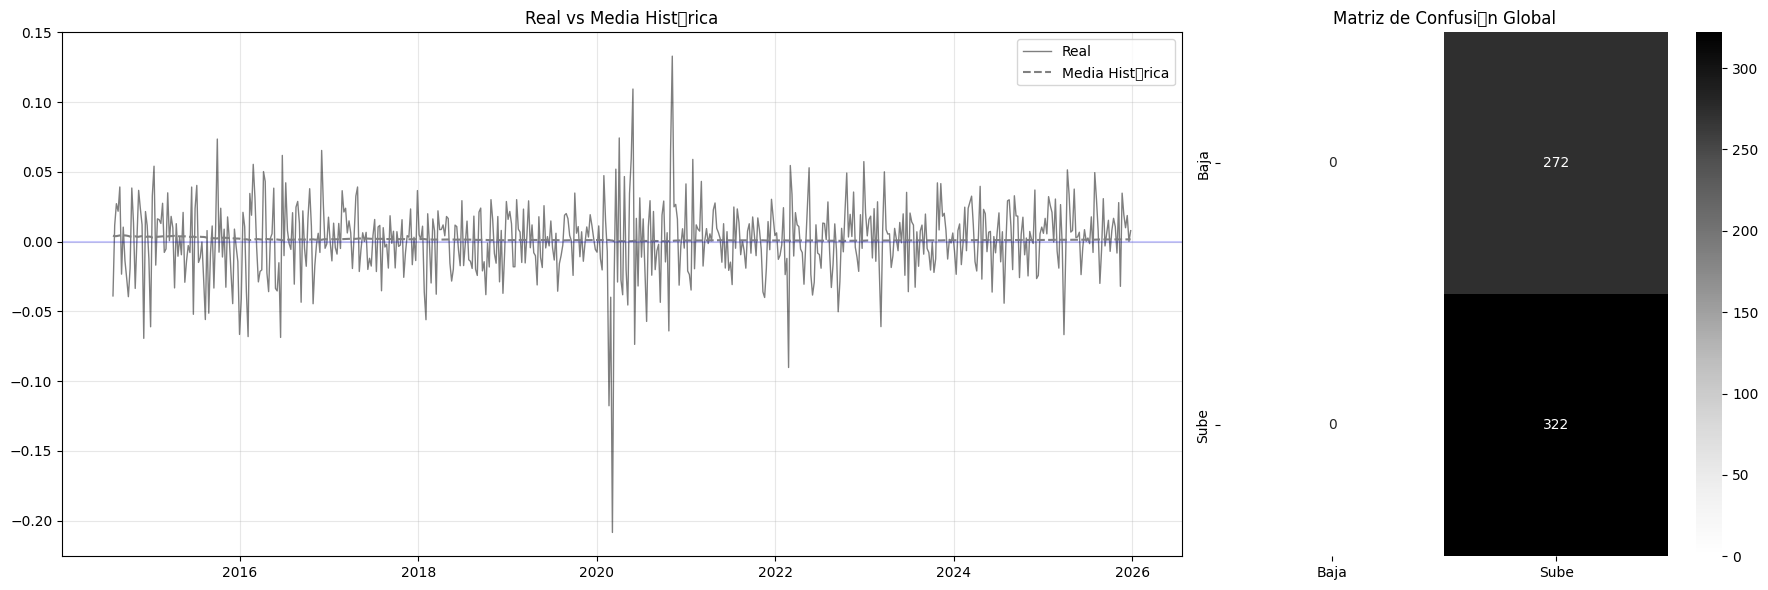

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (mean_squared_error, r2_score, cohen_kappa_score, confusion_matrix, accuracy_score)
import warnings
import os

warnings.filterwarnings('ignore')

# ── FUNCIONES DE CONTRASTES ESTADSTICOS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def pesaran_timmermann_test(y_true, y_pred):
    """Calcula el test de Pesaran-Timmermann para capacidad direccional."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n = len(y_true)
    p_hat = (y_true == y_pred).mean()
    p_y = (y_true == 1).mean()
    p_x = (y_pred == 1).mean()
    p_star = p_y * p_x + (1 - p_y) * (1 - p_x)

    v_p_hat = (p_star * (1 - p_star)) / n
    v_p_y = (2 * p_x - 1)**2 * (p_y * (1 - p_y) / n)
    v_p_x = (2 * p_y - 1)**2 * (p_x * (1 - p_x) / n)

    v_total = v_p_hat - v_p_y - v_p_x
    if v_total <= 0: return 0.0, 1.0

    z_stat = (p_hat - p_star) / np.sqrt(v_total)
    p_value = 1 - norm.cdf(abs(z_stat))
    return z_stat, p_value

# ── 1. CARGA DE DATOS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
file_path = '/content/ibex_tfg_weekly.csv'

if os.path.exists(file_path):
    try:
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()
        date_col = next((c for c in df.columns if c.lower() in ['date', 'fecha']), None)

        if date_col:
            df[date_col] = pd.to_datetime(df[date_col])
            df = df.sort_values(date_col)

        y = df[df.columns[-1]]
        print(f' Datos cargados correctamente. Filas: {len(df)}')

        tscv_6 = TimeSeriesSplit(n_splits=6)
        all_preds, all_actuals, all_dates = [], [], []
        fold_results_list = []

        print('\n--- EVALUACIN SISTEMTICA: MEDIA HISTRICA RECURSIVA (6 FOLDS) ---')

        for i, (train_idx, test_idx) in enumerate(tscv_6.split(y)):
            y_train, y_test = y.iloc[train_idx].values, y.iloc[test_idx].values

            if date_col:
                test_dates = df[date_col].iloc[test_idx]
                start_test, end_test = test_dates.min().strftime('%Y-%m-%d'), test_dates.max().strftime('%Y-%m-%d')
                all_dates.extend(test_dates.tolist())

            history = list(y_train)
            predictions = []

            for t in range(len(y_test)):
                yhat = np.mean(history)
                predictions.append(yhat)
                history.append(y_test[t])

            predictions = np.array(predictions)
            all_preds.extend(predictions)
            all_actuals.extend(y_test)

            # Criterio Homogeneizado: >= 0 es 1, < 0 es -1
            y_te_bin = np.where(y_test >= 0, 1, -1)
            preds_bin = np.where(predictions >= 0, 1, -1)

            cm = confusion_matrix(y_te_bin, preds_bin, labels=[-1, 1])
            acc = accuracy_score(y_te_bin, preds_bin)
            rec_baja = cm[0,0]/cm[0,:].sum() if cm[0,:].sum() > 0 else 0
            rec_sube = cm[1,1]/cm[1,:].sum() if cm[1,:].sum() > 0 else 0
            kappa = cohen_kappa_score(y_te_bin, preds_bin)
            rmse = np.sqrt(mean_squared_error(y_test, predictions))
            r2 = r2_score(y_test, predictions)

            fold_results_list.append({
                'Fold': i + 1, 'Inicio Test': start_test, 'Fin Test': end_test,
                'Accuracy': acc, 'Recall_Baja': rec_baja, 'Recall_Sube': rec_sube,
                'Kappa': kappa, 'RMSE': rmse, 'R2': r2
            })

        # --- TABLAS ---
        df_folds = pd.DataFrame(fold_results_list)
        df_folds_display = df_folds.copy()
        for col in ['Accuracy', 'Recall_Baja', 'Recall_Sube']:
            df_folds_display[col] = df_folds_display[col].apply(lambda x: f"{x:.2%}")
        df_folds_display['Kappa'] = df_folds_display['Kappa'].apply(lambda x: f"{x:.2f}")
        df_folds_display['RMSE'] = df_folds_display['RMSE'].apply(lambda x: f"{x:.4f}")
        df_folds_display['R2'] = df_folds_display['R2'].apply(lambda x: f"{x:.2f}")

        print('--- DESGLOSE DETALLADO POR FOLD ---')
        display(df_folds_display)

        # --- CONTRASTES ESTADSTICOS ---
        y_act, y_pre = np.array(all_actuals), np.array(all_preds)
        s_act, s_pre = np.where(y_act >= 0, 1, -1), np.where(y_pre >= 0, 1, -1)

        z_pt, p_pt = pesaran_timmermann_test(s_act, s_pre)

        print("\n" + "="*60)
        print("RESULTADOS DE CONTRASTES ESTADSTICOS (BENCHMARK)")
        print("="*60)
        print(f"1. Test de Pesaran-Timmermann (Capacidad Direccional):")
        print(f"   - Estadstico Z: {z_pt:.4f}")
        print(f"   - p-valor: {p_pt:.4f} -> " + ("(SIGNIFICATIVO)" if p_pt < 0.05 else "(NO SIGNIFICATIVO)"))
        print("="*60)

        # --- RESUMEN PROMEDIO ---
        avg_metrics = pd.DataFrame({
            'Mtrica': ['Accuracy Medio', 'Recall Baja Medio', 'Recall Sube Medio', 'Kappa Medio', 'RMSE Medio', 'R2 Medio'],
            'Valor': [f"{df_folds['Accuracy'].mean():.2%}", f"{df_folds['Recall_Baja'].mean():.2%}",
                      f"{df_folds['Recall_Sube'].mean():.2%}", f"{df_folds['Kappa'].mean():.2f}",
                      f"{df_folds['RMSE'].mean():.4f}", f"{df_folds['R2'].mean():.2f}"]
        })
        print('\n--- RESUMEN DE MTRICAS PROMEDIO (MEDIA HISTRICA) ---')
        display(avg_metrics)

        # --- GRFICAS ---
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [2, 1]})
        ax1.plot(all_dates, all_actuals, label='Real', color='black', alpha=0.5, linewidth=1)
        ax1.plot(all_dates, all_preds, label='Media Histrica', color='gray', linestyle='--', linewidth=1.5)
        ax1.axhline(0, color='blue', linestyle='-', alpha=0.2)
        ax1.set_title('Real vs Media Histrica')
        ax1.legend(); ax1.grid(True, alpha=0.3)

        sns.heatmap(confusion_matrix(np.where(y_act >= 0, 1, -1), np.where(y_pre >= 0, 1, -1), labels=[-1, 1]),
                    annot=True, fmt='d', cmap='Greys', xticklabels=['Baja', 'Sube'], yticklabels=['Baja', 'Sube'], ax=ax2)
        ax2.set_title('Matriz de Confusin Global')
        plt.tight_layout(); plt.show()

    except Exception as e:
        print(f'Error: {e}')
else:
    print(' ERROR: No se encontr el archivo.')

 Datos cargados correctamente. Archivo: ibex_tfg_weekly.csv | Filas: 697

--- EVALUACIÓN SISTEMÁTICA: MODELO NAIVE / PERSISTENCIA (6 FOLDS) ---
--- DESGLOSE DETALLADO POR FOLD (NAIVE) ---


,Fold,Inicio Test,Fin Test,Accuracy,Recall_Baja,Recall_Sube,Kappa,RMSE,R2
0,1,2014-08-01,2016-06-17,51.52%,52.00%,51.02%,0.03,0.0411,-0.83
1,2,2016-06-24,2018-05-11,45.45%,37.21%,51.79%,-0.11,0.0328,-1.42
2,3,2018-05-18,2020-04-03,48.48%,52.83%,43.48%,-0.04,0.0410,-0.70
3,4,2020-04-10,2022-02-25,44.44%,40.43%,48.08%,-0.12,0.0452,-1.00
4,5,2022-03-04,2024-02-02,49.49%,44.44%,53.70%,-0.02,0.0341,-1.29
5,6,2024-02-09,2025-12-26,48.48%,26.47%,60.00%,-0.13,0.0293,-1.02



RESULTADOS DE CONTRASTES ESTADÍSTICOS (NAIVE VS MEDIA)
1. Test de Pesaran-Timmermann (Capacidad Direccional):
   - Estadístico Z: -1.1584
   - p-valor: 0.1234 -> (NO SIGNIFICATIVO)

2. Contraste Diebold-Mariano (Naive vs Media Histórica):
   - Estadístico DM: -6.2461
   - p-valor: 0.0000 -> (SIGNIFICATIVO)

--- RESUMEN DE MÉTRICAS PROMEDIO (NAIVE) ---


,Métrica,Valor
0,Accuracy Medio,47.98%
1,Recall Baja Medio,42.23%
2,Recall Sube Medio,51.34%
3,Kappa Medio,-0.06
4,RMSE Medio,0.0373
5,R2 Medio,-1.04


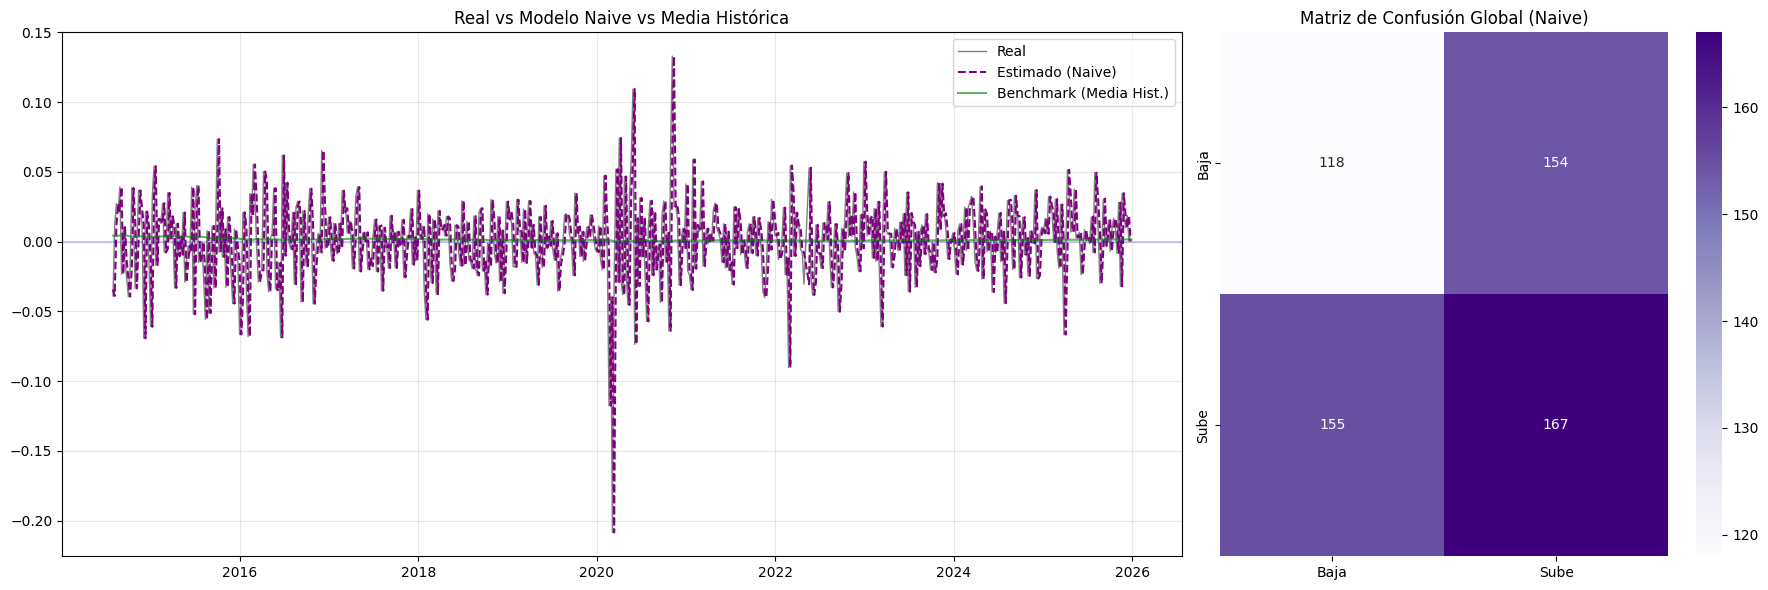

In [16]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (mean_squared_error, r2_score, cohen_kappa_score, confusion_matrix, accuracy_score)
import warnings
import os

warnings.filterwarnings('ignore')

# ── FUNCIONES DE CONTRASTES ESTADÍSTICOS ─────────────────────────────────

def pesaran_timmermann_test(y_true, y_pred):
    """Calcula el test de Pesaran-Timmermann para capacidad direccional."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n = len(y_true)
    p_hat = (y_true == y_pred).mean()
    p_y = (y_true == 1).mean()
    p_x = (y_pred == 1).mean()
    p_star = p_y * p_x + (1 - p_y) * (1 - p_x)

    v_p_hat = (p_star * (1 - p_star)) / n
    v_p_y = (2 * p_x - 1)**2 * (p_y * (1 - p_y) / n)
    v_p_x = (2 * p_y - 1)**2 * (p_x * (1 - p_x) / n)

    v_total = v_p_hat - v_p_y - v_p_x
    if v_total <= 0: return 0.0, 1.0

    z_stat = (p_hat - p_star) / np.sqrt(v_total)
    p_value = 1 - norm.cdf(abs(z_stat))
    return z_stat, p_value

def diebold_mariano_test(y_true, y_pred, y_benchmark):
    """Contraste DM: Compara el modelo (Naive) vs Benchmark (Media Histórica)."""
    e_mod = (y_true - y_pred)**2
    e_ben = (y_true - y_benchmark)**2
    d = e_ben - e_mod
    d_bar = np.mean(d)
    v_d = np.var(d, ddof=1) / len(d)
    if v_d <= 0: return 0.0, 1.0

    dm_stat = d_bar / np.sqrt(v_d)
    p_value = 1 - norm.cdf(abs(dm_stat))
    return dm_stat, p_value

# ── 1. CARGA DE DATOS (tfg) ──────────────────────────────────────────────
file_path = '/content/ibex_tfg_weekly.csv'

if os.path.exists(file_path):
    try:
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()
        date_col = next((c for c in df.columns if c.lower() in ['date', 'fecha']), None)

        if date_col:
            df[date_col] = pd.to_datetime(df[date_col])
            df = df.sort_values(date_col)

        y = df[df.columns[-1]]
        print(f' Datos cargados correctamente. Archivo: {os.path.basename(file_path)} | Filas: {len(df)}')

        tscv_6 = TimeSeriesSplit(n_splits=6)
        all_preds, all_actuals, all_dates, all_bench_hist = [], [], [], []
        fold_results_list = []

        print('\n--- EVALUACIÓN SISTEMÁTICA: MODELO NAIVE / PERSISTENCIA (6 FOLDS) ---')

        for i, (train_idx, test_idx) in enumerate(tscv_6.split(y)):
            y_train, y_test = y.iloc[train_idx].values, y.iloc[test_idx].values

            if date_col:
                test_dates = df[date_col].iloc[test_idx]
                start_test, end_test = test_dates.min().strftime('%Y-%m-%d'), test_dates.max().strftime('%Y-%m-%d')
                all_dates.extend(test_dates.tolist())

            history = list(y_train)
            predictions = []
            historical_means = []

            # Walk-Forward: El modelo predice que t será igual a t-1
            for t in range(len(y_test)):
                # Predicción Naive
                yhat = history[-1]
                predictions.append(yhat)

                # Benchmark: Media Histórica (Promedio acumulado hasta ese instante)
                y_mean = np.mean(history)
                historical_means.append(y_mean)

                # Actualizar historia para el siguiente paso
                history.append(y_test[t])

            predictions = np.array(predictions)
            all_preds.extend(predictions)
            all_actuals.extend(y_test)
            all_bench_hist.extend(historical_means) # Referencia Media Histórica para DM

            # Criterio Homogeneizado: >= 0 es 1, < 0 es -1
            y_te_bin = np.where(y_test >= 0, 1, -1)
            preds_bin = np.where(predictions >= 0, 1, -1)

            cm = confusion_matrix(y_te_bin, preds_bin, labels=[-1, 1])
            acc = accuracy_score(y_te_bin, preds_bin)
            rec_baja = cm[0,0]/cm[0,:].sum() if cm[0,:].sum() > 0 else 0
            rec_sube = cm[1,1]/cm[1,:].sum() if cm[1,:].sum() > 0 else 0
            kappa = cohen_kappa_score(y_te_bin, preds_bin)
            rmse = np.sqrt(mean_squared_error(y_test, predictions))
            r2 = r2_score(y_test, predictions)

            fold_results_list.append({
                'Fold': i + 1, 'Inicio Test': start_test, 'Fin Test': end_test,
                'Accuracy': acc, 'Recall_Baja': rec_baja, 'Recall_Sube': rec_sube,
                'Kappa': kappa, 'RMSE': rmse, 'R2': r2
            })

        # --- TABLAS ---
        df_folds = pd.DataFrame(fold_results_list)
        df_folds_display = df_folds.copy()
        for col in ['Accuracy', 'Recall_Baja', 'Recall_Sube']:
            df_folds_display[col] = df_folds_display[col].apply(lambda x: f"{x:.2%}")
        df_folds_display['Kappa'] = df_folds_display['Kappa'].apply(lambda x: f"{x:.2f}")
        df_folds_display['RMSE'] = df_folds_display['RMSE'].apply(lambda x: f"{x:.4f}")
        df_folds_display['R2'] = df_folds_display['R2'].apply(lambda x: f"{x:.2f}")

        print('--- DESGLOSE DETALLADO POR FOLD (NAIVE) ---')
        display(df_folds_display)

        # --- CONTRASTES ESTADÍSTICOS ---
        y_act, y_pre, y_bench = np.array(all_actuals), np.array(all_preds), np.array(all_bench_hist)
        s_act, s_pre = np.where(y_act >= 0, 1, -1), np.where(y_pre >= 0, 1, -1)

        z_pt, p_pt = pesaran_timmermann_test(s_act, s_pre)
        dm_stat, p_dm = diebold_mariano_test(y_act, y_pre, y_bench)

        print("\n" + "="*60)
        print("RESULTADOS DE CONTRASTES ESTADÍSTICOS (NAIVE VS MEDIA)")
        print("="*60)
        print(f"1. Test de Pesaran-Timmermann (Capacidad Direccional):")
        print(f"   - Estadístico Z: {z_pt:.4f}")
        print(f"   - p-valor: {p_pt:.4f} -> " + ("(SIGNIFICATIVO)" if p_pt < 0.05 else "(NO SIGNIFICATIVO)"))

        print(f"\n2. Contraste Diebold-Mariano (Naive vs Media Histórica):")
        print(f"   - Estadístico DM: {dm_stat:.4f}")
        print(f"   - p-valor: {p_dm:.4f} -> " + ("(SIGNIFICATIVO)" if p_dm < 0.05 else "(NO SIGNIFICATIVO)"))
        print("="*60)

        # --- RESUMEN PROMEDIO ---
        avg_metrics = pd.DataFrame({
            'Métrica': ['Accuracy Medio', 'Recall Baja Medio', 'Recall Sube Medio', 'Kappa Medio', 'RMSE Medio', 'R2 Medio'],
            'Valor': [f"{df_folds['Accuracy'].mean():.2%}", f"{df_folds['Recall_Baja'].mean():.2%}",
                      f"{df_folds['Recall_Sube'].mean():.2%}", f"{df_folds['Kappa'].mean():.2f}",
                      f"{df_folds['RMSE'].mean():.4f}", f"{df_folds['R2'].mean():.2f}"]
        })
        print('\n--- RESUMEN DE MÉTRICAS PROMEDIO (NAIVE) ---')
        display(avg_metrics)

        # --- GRÁFICAS ---
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [2, 1]})
        ax1.plot(all_dates, all_actuals, label='Real', color='black', alpha=0.5, linewidth=1)
        ax1.plot(all_dates, all_preds, label='Estimado (Naive)', color='purple', linestyle='--', linewidth=1.5)
        ax1.plot(all_dates, all_bench_hist, label='Benchmark (Media Hist.)', color='green', alpha=0.6)
        ax1.axhline(0, color='blue', linestyle='-', alpha=0.2)
        ax1.set_title('Real vs Modelo Naive vs Media Histórica')
        ax1.legend(); ax1.grid(True, alpha=0.3)

        sns.heatmap(confusion_matrix(s_act, s_pre, labels=[-1, 1]),
                    annot=True, fmt='d', cmap='Purples', xticklabels=['Baja', 'Sube'], yticklabels=['Baja', 'Sube'], ax=ax2)
        ax2.set_title('Matriz de Confusión Global (Naive)')
        plt.tight_layout(); plt.show()

    except Exception as e:
        print(f'Error: {e}')
else:
    print(f' ERROR: No se encontró el archivo en {file_path}.')

--- SHAP VALUES RECONSTRUIDOS (Variables Originales) ---


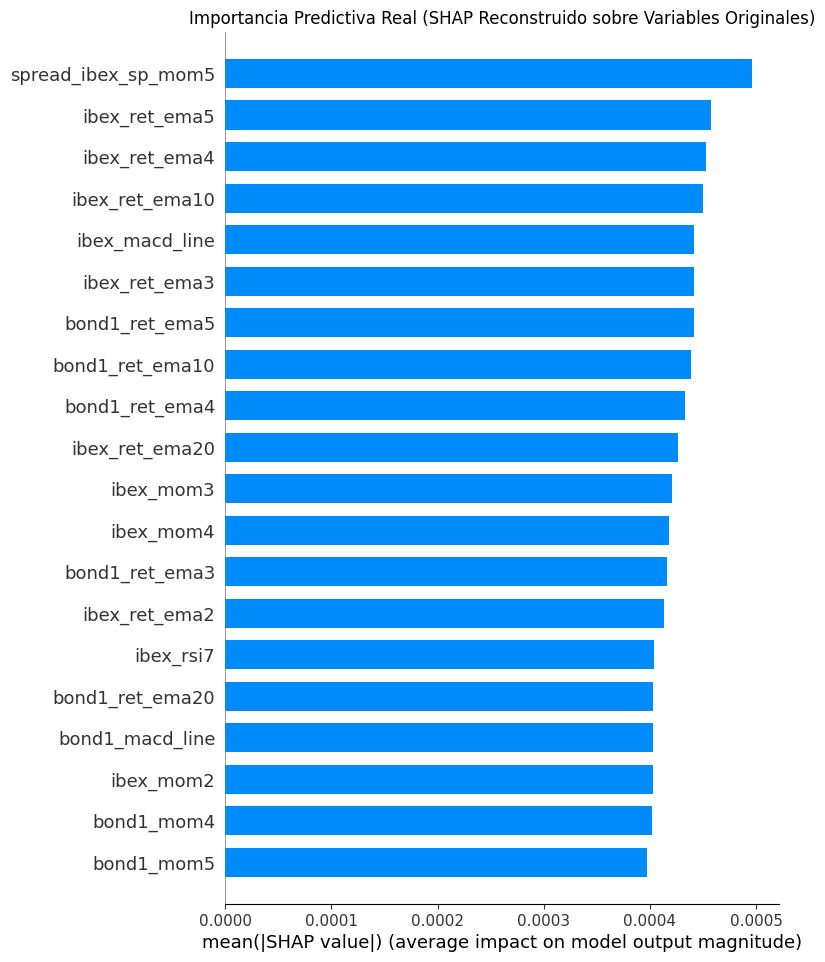


--- TOP 10 VARIABLES SEGÚN SHAP RECONSTRUIDO ---


,Variable,SHAP_Abs_Medio
293,spread_ibex_sp_mom5,0.000496
17,ibex_ret_ema5,0.000458
16,ibex_ret_ema4,0.000453
18,ibex_ret_ema10,0.000450
21,ibex_macd_line,0.000442
15,ibex_ret_ema3,0.000441
177,bond1_ret_ema5,0.000441
178,bond1_ret_ema10,0.000438
176,bond1_ret_ema4,0.000433
19,ibex_ret_ema20,0.000426


In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. ENTRENAMIENTO (Misma lógica de tu mejor modelo)
best_pca_indices = [0, 1, 3, 5]
sc = StandardScaler()
X_s = sc.fit_transform(X_num)
pca = PCA(n_components=max(best_pca_indices) + 1)
X_p = pca.fit_transform(X_s)

# Entrenamos con los PCs seleccionados
X_model = X_p[:, best_pca_indices]
model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05)
model.fit(X_model, y)

# 2. CÁLCULO DE SHAP VALUES (Sobre los PCs)
explainer = shap.TreeExplainer(model)
shap_values_pcs = explainer.shap_values(X_model)

# 3. PROYECCIÓN DE SHAP A VARIABLES ORIGINALES

components = pca.components_[best_pca_indices, :] # Matriz (n_pcs, n_features)
shap_values_original = np.dot(shap_values_pcs, components)

# 4. VISUALIZACIÓN: SHAP SUMMARY PLOT RECONSTRUIDO
# Convertimos a DataFrame para que los nombres de las variables salgan en el gráfico
df_shap_orig = pd.DataFrame(shap_values_original, columns=X_num.columns)

print("--- SHAP VALUES RECONSTRUIDOS (Variables Originales) ---")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_original, X_num, plot_type="bar", show=False)
plt.title('Importancia Predictiva Real (SHAP Reconstruido sobre Variables Originales)')
plt.show()

# 5. ANÁLISIS DE CONTRIBUCIÓN MEDIA
mean_shap_importance = np.abs(shap_values_original).mean(axis=0)
df_final_shap = pd.DataFrame({
    'Variable': X_num.columns,
    'SHAP_Abs_Medio': mean_shap_importance
}).sort_values(by='SHAP_Abs_Medio', ascending=False)

print("\n--- TOP 10 VARIABLES SEGÚN SHAP RECONSTRUIDO ---")
display(df_final_shap.head(10))

✅ Datos cargados: 697 filas. Iniciando Backtesting Maestro con Parámetros Específicos...

⏳ Procesando Fold 1/6...
⏳ Procesando Fold 2/6...
⏳ Procesando Fold 3/6...
⏳ Procesando Fold 4/6...
⏳ Procesando Fold 5/6...
⏳ Procesando Fold 6/6...


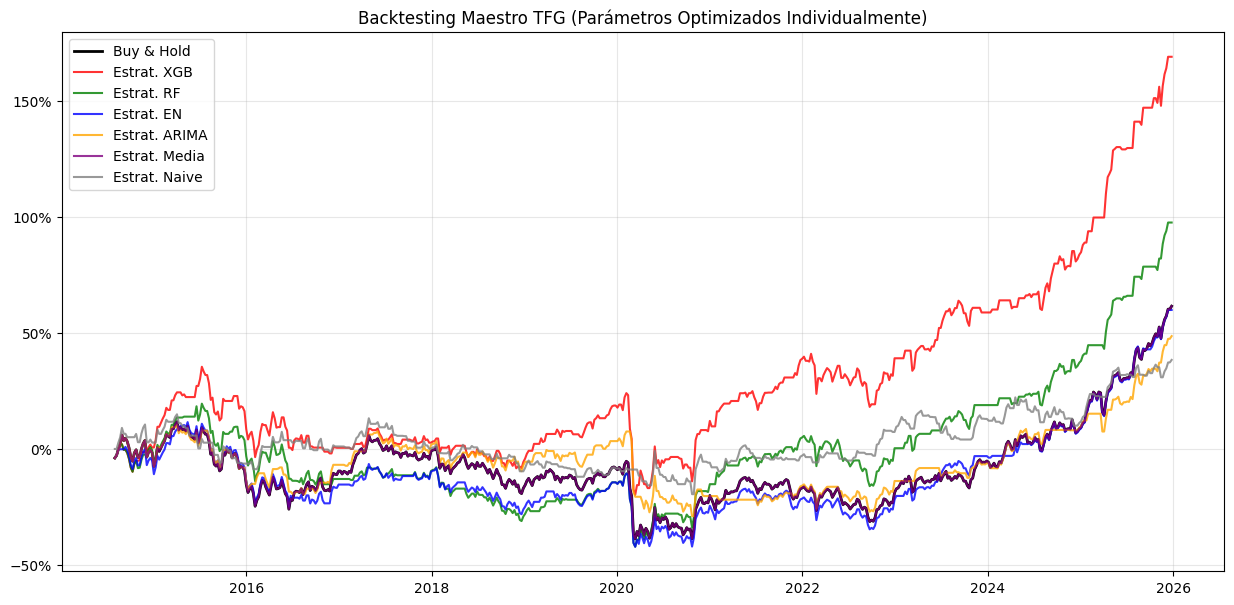

🏆 RENTABILIDAD FINAL:
Est_XGB      168.823832
Est_RF        97.472164
Real          61.463868
Est_Media     61.463868
Est_EN        59.830855
Est_ARIMA     48.579285
Est_Naive     38.327781
Name: 2025-12-26 00:00:00, dtype: float64


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Machine Learning
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit

# Series Temporales
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings('ignore')

# ==========================================
# 0. CARGA Y PREPARACIÓN DE DATOS
# ==========================================
file_path = '/content/ibex_tfg_weekly.csv'

if not os.path.exists(file_path):
    raise FileNotFoundError(f" ERROR: No se encontró {file_path}. Súbelo a /content/.")

df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
date_col = next((c for c in df.columns if c.lower() in ['date', 'fecha']), None)

if date_col:
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

target_col = df.columns[-1]
y = df[target_col]

cols_to_drop = [target_col]
if date_col: cols_to_drop.append(date_col)
X_num = df.select_dtypes(include=[np.number]).drop(columns=cols_to_drop, errors='ignore')

print(f' Datos cargados: {len(df)} filas. Iniciando Backtesting Maestro con Parámetros Específicos...\n')

# ==========================================
# 1. CONFIGURACIÓN DE MODELOS (SEGÚN EXPERIMENTOS)
# ==========================================
# Configuración XGB y RF
best_xgb_params = {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 3, 'random_state': 42}
best_rf_params = {'n_estimators': 200, 'max_depth': 4, 'random_state': 42}
best_pca_tree = [0, 1, 3, 5]
best_winsor_tree = (0.025, 0.025)

# Configuración Específica Elastic Net
best_en_params = {'alpha': 0.01, 'l1_ratio': 0.5, 'random_state': 42}
best_pca_en = [0, 1, 3, 5]
best_winsor_en = (0.05, 0.05) # EN prefiere mayor limpieza de outliers

PDQ_ARIMA = (2, 0, 2)

tscv_6 = TimeSeriesSplit(n_splits=6)

resultados = {
    'Real': [], 'Fechas': [],
    'XGB': [], 'RF': [], 'EN': [], 'ARIMA': [], 'Media': [], 'Naive': []
}

# ==========================================
# 2. BUCLE MAESTRO DE VALIDACIÓN (6 FOLDS)
# ==========================================
for i, (train_idx, test_idx) in enumerate(tscv_6.split(X_num)):
    print(f"⏳ Procesando Fold {i+1}/6...")

    if date_col:
        resultados['Fechas'].extend(df[date_col].iloc[test_idx].tolist())
    else:
        resultados['Fechas'].extend(range(len(resultados['Fechas']), len(resultados['Fechas']) + len(test_idx)))

    resultados['Real'].extend(y.iloc[test_idx].values)

    # --- RAMA PARA MODELOS DE ÁRBOLES (XGB, RF) ---
    X_tr_t, X_te_t = X_num.iloc[train_idx].copy(), X_num.iloc[test_idx].copy()
    for col in X_tr_t.columns:
        l, u = X_tr_t[col].quantile(best_winsor_tree[0]), X_tr_t[col].quantile(1 - best_winsor_tree[1])
        X_tr_t[col], X_te_t[col] = X_tr_t[col].clip(l, u), X_te_t[col].clip(l, u)

    sc_t = StandardScaler()
    X_tr_ts, X_te_ts = sc_t.fit_transform(X_tr_t), sc_t.transform(X_te_t)
    pca_t = PCA(n_components=max(best_pca_tree) + 1)
    X_tr_tp = pca_t.fit_transform(X_tr_ts)[:, best_pca_tree]
    X_te_tp = pca_t.transform(X_te_ts)[:, best_pca_tree]

    m_xgb = XGBRegressor(**best_xgb_params).fit(X_tr_tp, y.iloc[train_idx])
    resultados['XGB'].extend(m_xgb.predict(X_te_tp))
    m_rf = RandomForestRegressor(**best_rf_params).fit(X_tr_tp, y.iloc[train_idx])
    resultados['RF'].extend(m_rf.predict(X_te_tp))

    # --- RAMA PARA ELASTIC NET (Parámetros propios) ---
    X_tr_e, X_te_e = X_num.iloc[train_idx].copy(), X_num.iloc[test_idx].copy()
    for col in X_tr_e.columns:
        l, u = X_tr_e[col].quantile(best_winsor_en[0]), X_tr_e[col].quantile(1 - best_winsor_en[1])
        X_tr_e[col], X_te_e[col] = X_tr_e[col].clip(l, u), X_te_e[col].clip(l, u)

    sc_e = StandardScaler()
    X_tr_es, X_te_es = sc_e.fit_transform(X_tr_e), sc_e.transform(X_te_e)
    pca_e = PCA(n_components=max(best_pca_en) + 1)
    X_tr_ep = pca_e.fit_transform(X_tr_es)[:, best_pca_en]
    X_te_ep = pca_e.transform(X_te_es)[:, best_pca_en]

    m_en = ElasticNet(**best_en_params).fit(X_tr_ep, y.iloc[train_idx])
    resultados['EN'].extend(m_en.predict(X_te_ep))

    # --- RAMA SERIES TEMPORALES ---
    history = list(y.iloc[train_idx].values)
    y_test_ts = y.iloc[test_idx].values
    for t in range(len(y_test_ts)):
        resultados['Naive'].append(history[-1])
        resultados['Media'].append(np.mean(history))
        try:
            m_arima = ARIMA(history, order=PDQ_ARIMA).fit()
            resultados['ARIMA'].append(m_arima.forecast()[0])
        except: resultados['ARIMA'].append(np.mean(history))
        history.append(y_test_ts[t])

# ==========================================
# 3. RESULTADOS Y GRÁFICO
# ==========================================
df_res = pd.DataFrame(resultados).set_index('Fechas')
modelos = ['XGB', 'RF', 'EN', 'ARIMA', 'Media', 'Naive']

for m in modelos:
    df_res[f'Est_{m}'] = np.where(df_res[m] >= 0, 1, 0) * df_res['Real']

df_acum = (1 + df_res[['Real'] + [f'Est_{m}' for m in modelos]]).cumprod() - 1

plt.figure(figsize=(15, 7))
plt.plot(df_acum['Real'], label='Buy & Hold', color='black', lw=2)
colores = {'XGB':'red', 'RF':'green', 'EN':'blue', 'ARIMA':'orange', 'Media':'purple', 'Naive':'grey'}
for m in modelos:
    plt.plot(df_acum[f'Est_{m}'], label=f'Estrat. {m}', color=colores[m], alpha=0.8)

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Backtesting TFG (Parámetros Optimizados Individualmente)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

print(" RENTABILIDAD FINAL:")
print((df_acum.iloc[-1] * 100).sort_values(ascending=False))

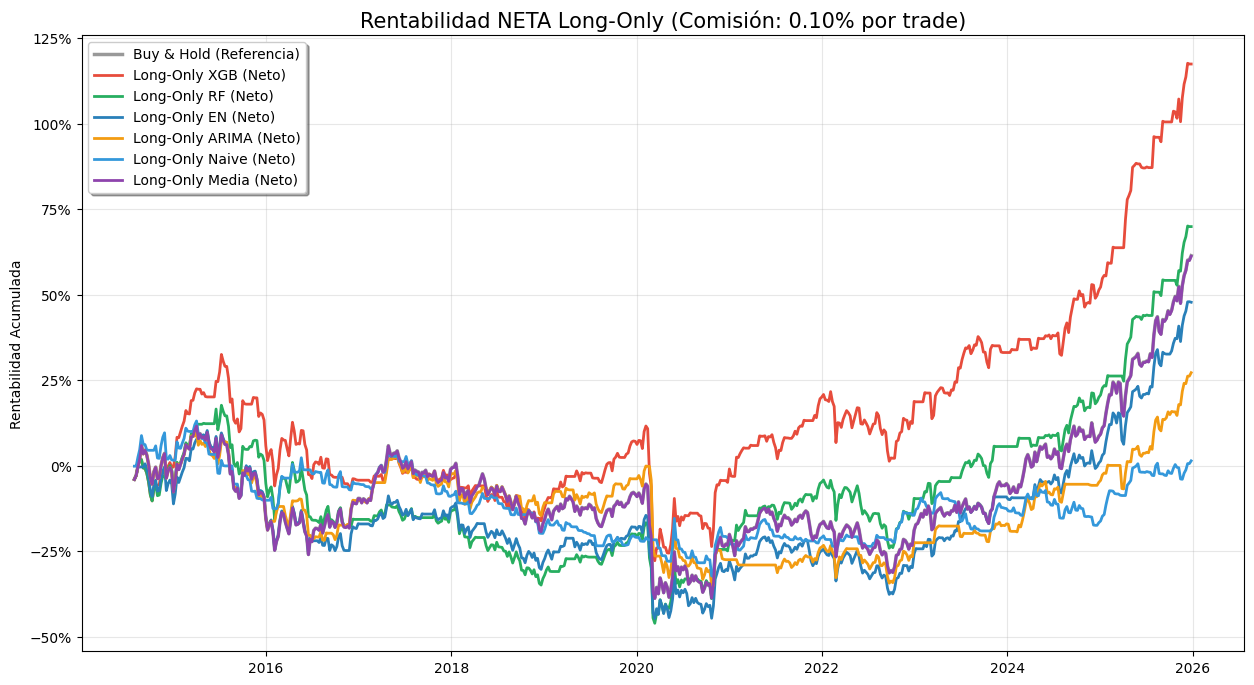

🏆 RANKING RENTABILIDAD NETA (LONG-ONLY) 


,% Rentabilidad Neta LO
Neto_XGB_LO,117.513890
Neto_RF_LO,69.968405
Buy & Hold,61.463868
Neto_Media_LO,61.295866
Neto_EN_LO,47.846094
Neto_ARIMA_LO,27.240406
Neto_Naive_LO,1.459893


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


# --- CONFIGURACIÓN ---
COMISION_LO = 0.0010  # 0.10% por operación
modelos_lo = ['XGB', 'RF', 'EN', 'ARIMA', 'Naive', 'Media']


df_neto_lo = pd.DataFrame(index=df_res.index)
df_neto_lo['Buy & Hold'] = df_res['Real']


for m in modelos_lo:
    # Posición: 1 (Largo) o 0 (Cash)
    posicion = np.where(df_res[m] >= 0, 1, 0)

    # Identificar trades (cambios de 0 a 1 o 1 a 0)
    cambios = np.abs(pd.Series(posicion).diff().fillna(1))
    costes = np.where(cambios != 0, COMISION_LO, 0)

    # Retorno Neto Long-Only
    df_neto_lo[f'Neto_{m}_LO'] = (posicion * df_res['Real']) - costes


# Rentabilidad Acumulada
df_acum_lo = (1 + df_neto_lo).cumprod() - 1


# --- VISUALIZACIÓN ---
plt.figure(figsize=(15, 8))
plt.plot(df_acum_lo.index, df_acum_lo['Buy & Hold'], label='Buy & Hold (Referencia)', color='black', linewidth=2.5, alpha=0.4)


colores = {'XGB': '#e74c3c', 'RF': '#27ae60', 'EN': '#2980b9', 'ARIMA': '#f39c12', 'Media': '#8e44ad', 'Naive': '#3498db'}


for m in modelos_lo:
    plt.plot(df_acum_lo.index, df_acum_lo[f'Neto_{m}_LO'], label=f'Long-Only {m} (Neto)', color=colores[m], linewidth=2)


plt.title(f'Rentabilidad NETA Long-Only (Comisión: {COMISION_LO*100:.2f}% por trade)', fontsize=15)
plt.ylabel('Rentabilidad Acumulada')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, alpha=0.3)
plt.show()


# Ranking
print("🏆 RANKING RENTABILIDAD NETA (LONG-ONLY) ")
ranking_lo = (df_acum_lo.iloc[-1] * 100).sort_values(ascending=False)
display(ranking_lo.to_frame('% Rentabilidad Neta LO'))